# ضبط نموذج Gemma على اللهجة العراقية (Fine-Tuning) — نسخة v8 (مضادة للنسيان الكارثي + إصلاح فجوات v6 الثلاث + دفعة v8 المركزة + دفعة v9 الأسلوبية + دفعة v10 التصحيحية من سجل الدروع)

هذا الدفتر يدرّب نموذج `google/gemma-4-12B-it` على بيانات اللهجة العراقية باستخدام تقنية **LoRA** ومكتبة **TRL (SFTTrainer)**.

## 🔧 تغييرات نسخة v6 (علاج النسيان الكارثي / فرط التخصيص)

النسخة السابقة (223 ألف مثال، LR=5e-5، تقييم مرة واحدة بنهاية الحقبة) أنتجت نموذجاً فقد قدرات Gemma الأساسية وصار يطابق شكل بيانات التدريب على أي مدخل. القياس الفعلي للبيانات كشف: **42.6% هياكل محادثات مكررة حرفياً**، 3,344 محادثة مكررة 100%، و**1,024 مثال validation موجودة داخل التدريب** (تلوث يجعل eval_loss كاذباً). التصحيحات:

1. **بيانات v6 المنظّفة** (`prepare_v6_data.py`): **71,458** مثالاً بعد إزالة التكرار الحرفي وتفريد الهياكل وموازنة الفئات وإزالة تلوث train/val — تقليص جرعة الانحراف للثلث.
1.5. **فلتر لهجة صارم**: حذف كل مثال فيه تعبير غير عراقي بردود البائع (لا يخالف/أبشر/خالص/منيح... — 2,472 مثالاً حُذف) + **القدرات الغائبة أُضيفت** عبر `generate_v6_extras.py`: استخراج JSON منها متعدد المنتجات (5,696)، استدعاء أدوات [TOOL_CALL] (2,860)، «أتأكدلك» لمعلومة ناقصة (2,605)، وتكرار السؤال بجواب ثابت (1,657) — كانت صفراً بالبيانات القديمة، وغيابها هو سبب فشل الموديل بهذه المهام.
2. **خلط 10–15% بيانات تعليمات عامة** (Aya بالعربية الفصحى + إنجليزي قليل) — خط الدفاع الأول ضد النسيان (Replay).
3. **تقييم كل 250 خطوة بدل نهاية الحقبة** + **إيقاف مبكر (EarlyStopping)** — مع حقبة واحدة، التقييم بنهايتها فقط لا يكشف الانهيار إلا بعد فوات الأوان.
4. **LR = 1e-4 مع LoRA** (القيمة القياسية) و**alpha = r = 16** بدل 32 — نسبة alpha/r=2 تضاعف قوة التحديث الفعلية وتسرّع محو قدرات الأساس.
5. **دفعة فعّالة 32** (8 × تراكم 4) — تدرجات أنعم = انحراف أقل.
6. **NEFTune** (ضوضاء على الـ embeddings) — يقلل الحفظ الحرفي ويحسّن التعميم.

## 🔧 تصحيحات مثبَّتة من النسخ السابقة (لا تلمسها)
- **transformers آخر إصدار**.
- **قائمة `target_modules` صريحة** بدل `all-linear` (تتجنب طبقات AltUp وأبراج الرؤية/الصوت).

**خطوات العمل:** تثبيت المكتبات ← إعادة تشغيل الجلسة ← تحميل بيانات v6 ← خلط البيانات العامة ← تحميل النموذج واختباره قبل التدريب ← تحليل الأطوال ← إعدادات التدريب ← التدريب (مع تقييم دوري وإيقاف مبكر) ← منحنى الخسارة ← اختبار النموذج المدرّب (مجال + قدرات عامة).

## 1. تثبيت المكتبات المطلوبة

تثبيت PyTorch ومكتبات Hugging Face: `transformers` للنماذج، `datasets` للبيانات، `trl` للتدريب بأسلوب SFT، و`peft` لتقنية LoRA، إضافة إلى `torchao` (مطلوبة لطبقات Gemma المخصصة) و`matplotlib` لرسم منحنى الخسارة لاحقاً.

In [1]:
# تثبيت PyTorch وأداة TensorBoard لمتابعة التدريب
%pip install torch tensorboard

# تثبيت مكتبات Hugging Face اللازمة للتدريب
%pip install datasets accelerate evaluate trl peft protobuf sentencepiece

# تحديث transformers لآخر إصدار
%pip install -U transformers

# تحديث torchao (مطلوبة لطبقات Gemma المخصصة) وتثبيت matplotlib للرسوم البيانية
%pip install --upgrade torchao matplotlib

# 🔄 بعد التثبيت: أعد تشغيل الجلسة (Runtime > Restart session) ثم كمّل من الخلية التالية

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 70.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 221.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

## 2. تحميل مستودع البيانات

استنساخ مستودع GitHub الذي يحتوي على ملفات بيانات التدريب باللهجة العراقية بصيغة JSONL.

In [1]:
!git clone https://github.com/ameer20042005/database_LLm.git

# Now you can access the files in the 'database_LLm' directory
# For example, to list the contents:
# !ls database_LLm

Cloning into 'database_LLm'...
remote: Enumerating objects: 2083, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 2083 (delta 33), reused 41 (delta 21), pack-reused 2028 (from 2)
Receiving objects: 100% (2083/2083), 123.11 MiB | 34.30 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Updating files: 100% (86/86), done.


## 3. قراءة البيانات وتجهيزها (v8 + v9 + v10 + v11)

قراءة ملفات **v8** من `data/` — أساسها v6 الناتج من `scripts/prepare_v6_data.py` الذي يجمع v4 (لهجة عامة) + v5 (كتالوج مؤرضن) بعد:

- **إزالة التكرار الحرفي** (محادثات مطابقة 100%) وتفريد الهياكل: نفس تسلسل رسائل الزبون يُحتفظ به مرة واحدة في v4، وحتى 3 مرات في v5 (لأن الكتالوجات المختلفة لنفس الأسئلة مقصودة — تعلّم القراءة من السياق).
- **إزالة تلوث train/val**: 1,024 مثالاً كانت موجودة حرفياً في الطرفين — حُذفت من التدريب.
- **موازنة الفئات**: سقف 1,600 مثال لكل فئة v4، وكسر هيمنة `grounded_catalog_copy` في v5 (من 28.5 ألف إلى 7 آلاف).
- **فحص تأريض الأرقام**: أي رد بائع فيه رقم غير موجود حرفياً بكتالوج المثال يُحذف.

- **فلتر لهجة صارم**: أي رد بائع فيه تعبير خليجي/مصري/شامي (لا يخالف، أبشر، خالص، منيح، هلق...) يُسقط المثال — يشمل «شو» الشامية وادعاءات المخزون/الندرة المحظورة بقسم 2 — القياس وجد 3,063 مثالاً ملوثاً بالبيانات القديمة.
- **القدرات الغائبة** (من `scripts/generate_v6_extras.py` وفق مواصفات AA.md): **استخراج JSON** بمخطط الطلب الثابت ومنها طلبات متعددة المنتجات (5,696 مثالاً)، **استدعاء الأدوات** بصيغة `[TOOL_CALL]` طلباً وصياغةً للنتيجة (2,860)، **«أتأكدلك وأرد عليك»** لمعلومة مو مكتوبة بالكتالوج (2,605)، و**تكرار السؤال مرتين بجواب ثابت** ضد الهذيان الدلالي (1,657) — كل رد فيها بدون أي رقم مخترع.

(ملفات v6 الوسيطة أُدمجت لاحقاً مع إضافات v7 أدناه.)

`data/greetings_smalltalk_only.jsonl` **غير مُحمَّل هنا عمداً**: نسخة مطابقة من محادثات التحية الموجودة أصلاً داخل train/val — تحميله يضاعف وزن فئة التحية.

الخلية التالية بعد التحميل تخلط **10–15% بيانات تعليمات عامة** — راجع شرحها هناك.


### إضافات v7 (سد الفجوات المقاسة باختبار إنتاج v6)
ناتج `scripts/generate_v7_extras.py` + `scripts/prepare_v7_data.py` (يعيد فحص المجموع الكامل: لهجة، تأريض أرقام، تكرار، تلوث):
- **ثبات الرفض تحت الإصرار** (2,571): الزبون يضغط 2–4 مرات (اكيد عندكم / كل المحلات عدها / بيش تبيعه؟ / ادفعلك زيادة) والبائع يثبت بكل دور — البديل يُعرض فقط إذا منطقي (نفس نوع المنتج من الكتالوج).
- **«أتأكدلك» موسّعة** (2,134): 9 صفات (الضمان 25% — الفشل المقاس)، مع 20% أمثلة تباينية الصفة فيها موجودة بالكتالوج فتُنسخ حرفياً.
- **JSON بمخطط ثابت** (2,541): `{"order": {"items": [...], "total": ...}}` بأرقام صحيحة بدون فواصل، total متحقق حسابياً، مع حالات تعديل الطلب ومنتج غير متوفر.
- **مدح بلا عرض بيعي** (659): رد مجاملة صافٍ بدون أي رقم أو منتج.

الملفات الوسيطة `iraqi_train_v7_part01..03.jsonl` أُدمجت مع دفعة v8 أدناه.

### إضافات v8 (دفعة مركزة على الأولويات الأربع + سد النواقص)
ناتج `scripts/generate_v8_batch.py` + `scripts/prepare_v8_data.py`:
- **«أتأكدلك» — الأولوية القصوى** (200): كتالوجات عشوائية متنوعة لكل مثال حتى يتعلم الموديل المبدأ لا حفظ المنتجات، مع 20% أمثلة تباينية (الصفة موجودة فتُنسخ حرفياً). منها 40 مثالاً بصفتين كانتا ناقصتين: **الأبعاد** و**برامج الغسيل** — بمولد مقيد بمنتجات منطقية للصفة (أبعاد → أجهزة/أثاث، برامج غسيل → غسالة/جلاية).
- **JSON صارم بكميات مختلطة** (150): ~85% من الأمثلة فيها بندان+ بكميات مختلفة (2 من هذا، 1 من ذاك)، وتشمل تعديل الطلب («لا خلي وحدة بس») بإعادة إخراج JSON كامل — total متحقق حسابياً.
- **مقاومة الضغط** (100): 50 إصرار على منتج غير متوفر (اكيد عندكم / ادفعلك زيادة) + 50 **ضغط خصم متكرر** على منتج متوفر (نزللي السعر / المحل الثاني أرخص / آني زبون قديم) والبائع يثبت على سعر الكتالوج حرفياً عبر 2–3 أدوار — v5 كانت عندها مساومة بدور واحد فقط، فهذي سد فجوة السايكوفانسي الفعلية.
- **بدون upselling** (100): 50 رد مدح بلا أي عرض بيعي + 50 **تلبية طلب** (`order_no_upsell`): الزبون يطلب منتجاً والبائع يلبي بدون اقتراح أي إضافة — فلتر يرفض أي منتج آخر أو عبارة عرض بالرد.

**إصلاح جديد في prepare_v8:** منع تشارك **الهياكل** (تسلسل رسائل الزبون) بين train/val وليس فقط التطابق الحرفي — حُذف 3,113 مثالاً مسرب الهيكل كان موجوداً منذ v7، فالتقييم الآن أصدق.

الملفات النهائية: `iraqi_train_v8_part01..03.jsonl` (**75,998** مثالاً) و`iraqi_val_v8.jsonl` (**15,480**) — صفر تسريب حرفي وهيكلي بين train/val.

### إضافات v9 (دفعة أسلوبية جديدة)
`data/iraqi_v9_generated.jsonl` — 40 محادثة مولّدة يدوياً بلهجة السماوة الجنوبية، كتالوج مختلف بكل محادثة (منتجات وأسعار وخصومات متغيرة حتى يتعلم الموديل النسخ من السياق):
- **بيع طبيعي** (10): سؤال سعر، مقارنة، مساومة مع ثبات على السعر، إعادة سعر ذُكر ببداية المحادثة حرفياً.
- **رفض متسلسل** (6): براندان-ثلاثة غير متوفرة بالتوالي، كل براند يُرفض باسمه الصحيح وبصيغة مختلفة، مع ثبات تحت الإصرار.
- **معلومة ناقصة** (6): ضمان/لون/بلد منشأ/توصيل/تركيب/برنامج غسيل مو بالكتالوج → «أتأكدلك وأرد عليك» بصياغات متنوعة وبمواقع مختلفة من المحادثة.
- **طلب واجمالي** (6): «لحظة أحسبلك اياه» بست صياغات، بدون ذكر أي رقم اجمالي.
- **استخراج JSON** (6): مخطط `{"items": [{"name", "qty"}], "install"}` حصراً، بدون أسعار ولا اجمالي، أسماء منسوخة من الكتالوج حرفياً.
- **تحيات ومجاملات** (6): ردود دافئة قصيرة غير مكررة.

يُحمَّل الملف مع أجزاء v8 في خلية القراءة أدناه (كله تدريب — التقييم يبقى على `iraqi_val_v8.jsonl`).


### إضافات v10 التصحيحية (سد فجوات سجل تدخلات الدروع)
ناتج `scripts/generate_v10_corrective.py` + تحقق `scripts/validate_v10.py` (كل الفحوص عدّت):
- **`iraqi_v10_corrective.jsonl` (695)**: ست فئات سلوكية بالاتجاهين (52% إحالة / 47% إجابة من الكتالوج، وكتالوج مختلف بكل محادثة):
  1. **تفصيلة داخل موضوع مرخّص** (160): الكتالوج يذكر «ضمان سنتين» والزبون يسأل عن الكومبريسر/الكسر → يجاوب المكتوب ويحيل التفصيلة؛ والاتجاه المقابل كتالوجه يفصّل التغطية فيُجاوب حرفياً. نفس النمط على التوصيل (مناطق فرعية) والتركيب (المواد) والاستهلاك.
  2. **مواصفات غير مذكورة** (120): لون/وزن/أبعاد/ضجيج/منشأ/غاز → إحالة مباشرة بلا تهرّب ولا تقليل من سؤال الزبون.
  3. **سياسات المحل** (115): تقسيط/استرجاع/حجز/دفع إلكتروني/فتح صندوق → إحالة بلا **نفي واثق** («ما نتعامل» كذبة محتملة مثل «نتعامل»)، والاتجاه المقابل كتالوجه يذكر السياسة فتُنسخ.
  4. **الالتزام بموضوع السؤال** (100): صيانة≠ضمان، توصيل≠تركيب، خصم≠عرض، حجز≠شراء — يجاوب عن المسؤول عنه حصراً بلا قفز للموضوع المجاور.
  5. **الجمع فوگ المجاميع المسبقة** (120): مجموع مكتوب + طلب تركيب/توصيل/قطعة ثالثة → يذكر الأرقام المكتوبة كلٌّ لحاله ويحيل الجمع للكاشير/النظام — **صفر أرقام مجاميع جديدة** (مفحوصة برمجياً).
  6. **التماسك الشرطي** (80): جمل شرطية عراقية سليمة (اذا ببغداد مجاني، واذا برا بغداد بـ20,000).
- **`iraqi_v10_extraction.jsonl` (160)**: نداء استخراج تفاصيل الشحنة (نفس `EXTRACT_DETAILS_SYSTEM` حرفياً) — 80 مثال **اسم بلا مؤشر** («ام حوراء بغداد...») و80 مثال **احتفاظ بصيغة المدينة** («الحله» → «الحلة» تصحيح إملائي فقط، بلا ترقية لـ«بابل»؛ ومنها 10 يكتب الزبون اسم المحافظة فتظل مثل ما هي).
- **`iraqi_v10_items.jsonl` (120)**: نداء استخراج المنتجات (`EXTRACT_ITEMS_SYSTEM` بكتالوجات متغيرة) — كميات بالكلمات، أسماء جزئية/ملهجة، تعديل وسط الطلب، تجاهل منتج برا الكتالوج، أعلام install، وطلبات موزعة على جمل.

### إضافات v11 لسدّ الفجوات الست الباقية (`iraqi_v11_gaps.jsonl` — 163 مثال)
ناتج `scripts/generate_v11_gaps.py` (فحص ذاتي مدمج يمنع الكتابة عند أي مخالفة). عمود النسبة محسوب على دفعة مرجعية N=1200 كما بجدول الفجوات الأصلي:

| الفجوة | الفئة | العدد | النسبة @N=1200 | المعالجة |
|---|---|---|---|---|
| تنويع صيغ الإحالة | `gap1_referral_variety` | 10 | 0.8% | ١٠ صيغ مختلفة، **مثال واحد لكل صيغة** حتى ما تُحفظ جملة إحالة وحدة وتتكرر |
| مجاملات وسوالف جانبية | `gap2_smalltalk_return` | 36 | 3.0% | رد قصير + إرجاع فوري للطلب — بلا مجاراة سالفة ولا رأي سياسي/ديني ولا سؤال شخصي مقابل |
| صياغة أسئلة الحقول | `gap3_slot_questions` | 30 | 2.5% | ٤ حقول × ٢ صيغة × (سؤال عادي + إعادة سؤال) + سلاسل حقلين وحالات «انطى حقلين دفعة وحدة» |
| صياغة عرض البدائل | `gap4_alternatives_phrasing` | 18 | 1.5% | الكود يجهز القائمة والنموذج يصيغ: بديل/بديلين/ثلاثة + حالة رفض الزبون كل البدائل بلا ضغط |
| تغيير الرأي وسط الطلب | `gap5_midorder_change` | 24 | 2.0% | إلغاء (6)، تعديل كمية (8)، رجوع للتصفح/تبديل منتج (10) — مع تثبيت الحالة الجديدة صراحة |
| تعزيز مضاد للتودد | `gap6_anti_sycophancy` | **45** | 3.8% | **حصة تثبيت إجبارية مو فجوة** — ثمانية أنماط ضغط: صمود بالسعر (6)، ضغط مكرر (6)، مقدمة كاذبة (6)، تهديد بالمغادرة (6)، استعطاف عاطفي (6)، ادعاء سلطة (5)، طُعم الرأي (5)، تصحيح خاطئ من الزبون (5) |
| **المجموع** | | **163** | | |

**التجانس السلوكي — الاعتبار الحاكم بهذي الدفعة.** كل الـ163 مثال يمشي على نفس العمود الفقري الثلاثي:

> (1) إقرار قصير جداً بكلام الزبون ← (2) الحقيقة من الكتالوج **بلا تنازل** ← (3) إرجاع للمهمة/الطلب

الفرق بين الفئات هو **المحفّز** (سالفة، طلب حقل، بديل، تغيير رأي، ضغط) مو **السلوك**. لو فئة المجاملات علّمت «جاوب باللي يرضّيه» وفئة مضادات التودد علّمت العكس، النموذج يتعلم تناقضاً ويرجّح الأكثر عدداً — أي التودد (sycophantic fine-tuning). هنا كلها تعلّم نفس الشي: **ودّي بالنبرة، صلب بالمحتوى**.

قواعد مفروضة برمجياً على كل الفئات بلا استثناء (يمنع السكربت الكتابة عند أي خرق):
- **صفر رقم** برد البائع غير موجود حرفياً بكتالوج نفس المحادثة أو برسائل الزبون.
- **صفر انقلاب موقف** تحت الضغط: لو الزبون كرر أو ضغط أو زعل، الجواب الثاني نفس الأول بالمضمون (تتغير الصياغة بس).
- **صفر إطراء افتتاحي** على الزبون («سؤال ممتاز»، «عندك حق تماماً»...) — الإقرار وظيفي فقط.
- **صفر وعد** غير مكتوب بالكتالوج (خصم، توفير لاحق، استثناء «خاص إلك»).
- **صفر فصحى أو لهجة غير عراقية** بردود البائع، وصفر تكرار لأول رسالة (تشابه >85% داخلياً وضد v8/v9/v10).

تحقق إضافي بـ`scripts/validate_v10.py`: 136/136 بنية سليمة، 284 رد مفحوص، وصفر مخالفة تأريض أرقام أو تكرار. (تبقى إشارة وحيدة على كلمة «خصم» بمثال ينفي وجود خصم — إيجابية كاذبة من مطابقة الكلمة المفتاحية بالدرع، والسلوك بالمثال هو المطلوب بالضبط.)

### التنظيف والترجيح — إصلاحان قبل التدريب

#### أ. تنظيف ادعاءات المخزون والخصومات (`scripts/clean_stock_claims.py`)

قسم 2 من AA.md يمنع منعاً باتاً بردود البائع: ادعاء المخزون («آخر قطعة»)، ادعاء الندرة («ما يجي ثاني»)، والخصومات غير المكتوبة بالكتالوج («سعر خاص»، «على خاطرك آخر سعر»). القياس وجد أن هذا المنع **لم يُطبَّق برمجياً قط**: التلوث أصله بيانات v4، وانتقل بالوراثة لـv6 وv7 وv8 لأن سكربتات `prepare_v*_data.py` نظّفت اللهجة والأرقام فقط.

| الملف | قبل | بعد | حُذف |
|---|---|---|---|
| `iraqi_train_v8_part01` | 25,332 | 24,852 | 480 |
| `iraqi_train_v8_part02` | 25,333 | 24,792 | 541 |
| `iraqi_train_v8_part03` | 25,333 | 24,765 | 568 |
| **`iraqi_val_v8`** (التقييم) | 15,480 | 14,997 | **483** |
| `iraqi_v9_generated` | 40 | 39 | 1 |
| **المجموع** | **91,518** | **89,445** | **2,073 (2.26%)** |

**الأخطر كان ملف التقييم.** `eval_loss` و`load_best_model_at_end` و`EarlyStoppingCallback` كلها تعتمد عليه، وفيه 483 محادثة تكافئ النموذج على تقليد السلوك الممنوع. أي أن النموذج لو تعلّم الصمود من `gap6` لارتفعت خسارته على تلك الأمثلة، وربما أوقف الإيقاف المبكر التدريب **لأنه تحسّن**. تنظيف التدريب وحده كان سيترك المقياس مقلوباً.

الفحص يجري على **ردود assistant فقط** (كلام الزبون حر)، وتُحذف المحادثة كاملة لا الرسالة وحدها حتى لا ينكسر التسلسل. النسخ الاحتياطية بـ`data/_backup_pre_clean/`. النتيجة بعد التنظيف: **صفر مخالفة** بكل الملفات.

#### ب. الترجيح بالتكرار على مستوى الفئة

الأحجام الخام تجعل الدفعات التصحيحية غير مرئية للتدرج: بدفعة فعّالة 32 وحوالي 2,600 خطوة، v9 وv11 يمرّان بمعدل **0.05 مثال بالخطوة** — 19 خطوة من كل 20 لا ترى منهما شيئاً.

الترجيح بالدفعة (معامل واحد لكل ملف) يوازن الدفعات فيما بينها لكنه يترك تفاوت الفئات داخلها: بـv10 كان ×3 يعطي `cat5` حصة 0.13 بينما `items_dual_form` تبقى 0.01 — سبع فئات تحت 0.03. لذلك المعامل صار **لكل فئة** بمفتاح `(الدفعة، الفئة)`، يوصلها لعتبة ~0.10 مثال/خطوة.

| الدفعة | خام | بعد الترجيح | % من التدريب |
|---|---|---|---|
| v8 (الأساس، ×1) | 74,409 | 74,409 | 89.2% |
| v9 | 119 | 1,741 | 2.1% |
| v10 | 975 | 5,389 | 6.5% |
| v11 | 163 | 2,174 | 2.6% |

استثناءات مقصودة عن العتبة:
- **`gap6_anti_sycophancy` معزّزة ×2.4 فوق العتبة** (0.251 مثال/خطوة): مرساة سلوكية تنافس بقية البيانات كلها، لا يكفي أن تبلغ الحد الأدنى مثل باقي الفئات.

> **لماذا وُسّعت gap6 من 18 إلى 45 مثالاً خاماً:** بلوغ حصتها المعزّزة بـ18 مثالاً كان يتطلب معامل تكرار **×39** — أي 39 نسخة من كل مثال. وهذي بالذات آخر فئة يجوز أن تُحفظ حرفياً: المطلوب أن يتعلم النموذج **مبدأ** الصمود لا أن يحفظ 18 جملة، وإلا صمد بمواقفها بعينها وانهار بغيرها. بعد التوسعة صار المعامل **×16** بنفس الحصة تماماً — تنوّع حقيقي بدل تكرار.
- **`items_dual_form` ×12** (بدل 30): 8 أمثلة فريدة فقط، و×30 يعني 30 نسخة من كل مثال — خطر حفظ حرفي يفوق فائدة بلوغ العتبة. تبقى عند 0.037 مثال/خطوة عمداً، والخلية تنبّه عليها.

> **فخ انتُبه له:** اسم `json_extraction` موجود بـv8 (5,696 مثال) وبـv9 معاً. مفتاح الفئة وحدها كان يطبّق معامل v9 (×16) على نسخ v8 فينتفخ التدريب من 74 ألف إلى 160 ألف. المفتاح `(الدفعة، الفئة)` يمنع ذلك، وفحص العتبة المدمج بالخلية كشفه.

**خطر التكرار ومخفّفاته:** التكرار الحرفي مع NEFTune وحقبة واحدة فيه خطر حفظ محدود، مخفَّف بثلاثة أشياء: (1) كل مثال بهذي الدفعات كتالوجه وصياغته متفردة أصلاً (تشابه أول رسالة أقل من 85%)، (2) NEFTune بضجيج 5 يمنع رؤية النسخ متطابقة، (3) الخلط الكامل يبعثر النسخ فلا تتجمع بنفس الدفعة.

### توسعة v9 اليدوية (`iraqi_v9_generated_extra.jsonl` — 80 محادثة)
ناتج `scripts/generate_v9_extra.py`: محادثات مؤلفة يدوياً بنفس فئات v9 الأصلية وأسلوبها (لهجة جنوبية/سماوة، كتالوجات متغيرة، تأريض أرقام مفحوص): بيع طبيعي 20، رفض متسلسل 12، «أتأكدلك» 12، اجمالي بلا رقم 12، JSON بمخطط items/qty/install 12، تحيات 12. الملف يلتقطه glob `iraqi_v9_generated*.jsonl` تلقائياً.

### دفعة v12 — انضباط الطلب (250 مثال)

ثلاث فجوات **مقيسة على الداتا قبل التوليد** (`scripts/generate_v12_order.py`):

| الفجوة | القياس قبل v12 | فئات v12 |
|---|---|---|
| علامة `[ORDER_READY]` | **صفر** مثال بكل `data/` (~530 ألف سطر) | `ord1` (40 موجب) + `ord2` (55 سالب) + `ord3` (30 بوابة تأكيد) |
| رفض التثبيت بحقل ناقص | 30 مثال جزئي بـ v11 فقط | `ord4` (45) |
| نتيجة أداة فارغة | **صفر** من 12,000 محادثة أداة | `ord5` (40) |
| وسيطا `status` / `all` | **صفر** (order_id/phone حصراً) | `ord6` (40) |

**العلامة ما انتدربت أبداً** — فهي تُتعلَّم هنا من الصفر، لا «تُذكَّر». وهذا
يغيّر التصميم: الخطر مو النسيان، الخطر أن يتعلمها الموديل كـ**زينة ختام**
يكتبها بأي رد ودّي. لذلك السالب أكثر من الموجب عمداً (**3.25:1**)، والشرط
المُعلَّم مركّب — العلامة تنكتب إذا وفقط إذا:

1. الحقول الأربعة موجودة **بكلام الزبون حرفياً**، و
2. البائع لخّص وسأل تأكيد، و
3. الزبون أكد تأكيداً صريحاً لا لبس فيه.

`ord2` تغطي أخطر حالة: كلام **يشبه** التأكيد وهو مو تأكيد («اكيد هذا غالي!»،
«نعم بس خلي أفكر») — لأن «نعم/اكيد» لو ارتبطت بالعلامة بالتدريب تصير مفتاحاً
لفظياً يفتح طلباً ناقصاً.

`ord4` تعالج لقطة العنوان الوهمي: الزبون يضغط «ثبتلي» أو «دزه على العنوان
المعتاد»، والبائع **يرفض التثبيت** ويسأل عن الناقص بدل أن يخترعه. الفحص
الذاتي بالسكربت يرفض الملف إذا ذُكرت محافظة أو اسم ما جاء برسالة الزبون
حرفياً — والتحقق المستقل عدّ صفر اختراع عبر الفئات الست كلها.


In [ ]:
import os
import glob
import json
import pandas as pd
from datasets import Dataset, DatasetDict

# البيانات القديمة: ملفات v8 النهائية (ناتج prepare_v8_data.py — راجع مستودع database_LLm)
v8_files = sorted(glob.glob("/content/database_LLm/data/iraqi_train_v8_part*.jsonl"))
assert len(v8_files) == 3, f"متوقع 3 أجزاء v8، وجد {len(v8_files)} — تأكد من سحب آخر نسخة من المستودع"

# البيانات الجديدة: دفعة v9 + توسعتها اليدوية (بيع، رفض متسلسل، أتأكدلك، اجمالي بلا رقم، JSON بمخطط items/qty/install، تحيات)
v9_files = sorted(glob.glob("/content/database_LLm/data/iraqi_v9_generated*.jsonl"))
assert len(v9_files) >= 2, "ملف v9 غير موجود — تأكد من سحب آخر نسخة من المستودع"

# دفعة v10 التصحيحية (سد فجوات سجل الدروع: إحالة شرطية بالكتالوج + استخراج الشحنة والمنتجات)
v10_files = sorted(glob.glob("/content/database_LLm/data/iraqi_v10_*.jsonl"))
assert len(v10_files) == 3, f"متوقع 3 ملفات v10 (corrective/extraction/items)، وجد {len(v10_files)} — تأكد من سحب آخر نسخة"

# دفعة v11 لسدّ الفجوات الست الباقية (163 مثال): تنويع صيغ الإحالة، المجاملات
# والسوالف الجانبية، صياغة أسئلة الحقول، صياغة عرض البدائل، تغيير الرأي وسط
# الطلب، وحصة تثبيت مضادة للتودد. كلها بنفس العمود الفقري السلوكي
# (إقرار قصير → حقيقة من الكتالوج بلا تنازل → إرجاع للطلب) حتى ما يتعلم
# النموذج تناقضاً يرجّح فيه الإرضاء على الصحة.
v11_files = sorted(glob.glob("/content/database_LLm/data/iraqi_v11_gaps.jsonl"))
assert len(v11_files) == 1, "ملف v11 غير موجود — تأكد من سحب آخر نسخة من المستودع"

# دفعة v12 لانضباط الطلب (250 مثال) — تعالج ثلاث فجوات مقيسة على الداتا
# قبل التوليد، مو مقدّرة:
#   • [ORDER_READY] كانت **صفر** بكل ملفات data/ (~530 ألف سطر) — العلامة
#     ما انتدربت أبداً، فهي تُتعلَّم هنا من الصفر لا «تُذكَّر».
#   • نتيجة أداة فارغة: صفر مثال من 12,000 محادثة أداة — والاختراع يصير
#     بالضبط لمن ما تجي نتيجة.
#   • وسيطا status/all: صفر (كل الداتا القديمة order_id/phone حصراً).
# التوزيع سالب:موجب للعلامة = 3.25:1 عمداً، حتى ما يتعلمها الموديل
# كـ«زينة ختام» يكتبها بأي رد ودّي بدل شرط مركّب (اكتمال + ملخّص + تأكيد).
v12_files = sorted(glob.glob("/content/database_LLm/data/iraqi_v12_order.jsonl"))
assert len(v12_files) == 1, "ملف v12 غير موجود — تأكد من سحب آخر نسخة من المستودع"

# دفعة v13 لحدود النطاق والطلاقة العامة — تعالج فجوتين مقيستين على الداتا:
#   • **الرفض العام خارج نطاق البيع = صفر مثال.** مسح على 74,409 محادثة
#     مؤسَّسة بكتالوج: سؤال طبي داخل سياق بيع = صفر. وكل رفض موجود
#     (grounded_catalog_reject، persistence_refusal) مبني على محور واحد
#     «المنتج مو موجود» وينتهي حتماً بارتداد للكتالوج («بس أگدر أعرضلك...»).
#     التعميم الوحيد المتاح للموديل كان «أي سؤال = فرصة أعرض منتج» — وهذا
#     بالضبط السلوك الخطأ لمن يجي سؤال طبي أو شخصي أو ديني.
#   • **فئات الطلاقة العامة شبه معدومة**: greetings_sys بمثال واحد،
#     jokes_banter/praise_expressions/negative_traits/smalltalk_sys بأربعة
#     لكل وحدة — بينما التقييم يقيسها (greetings بـ99 مثال).
v13_files = sorted(glob.glob("/content/database_LLm/data/iraqi_v13_scope.jsonl"))
assert len(v13_files) == 1, "ملف v13 غير موجود — تأكد من سحب آخر نسخة من المستودع"

# التقييم: v8 (يغطي فئات v8) + v13 (يغطي الفئات الجديدة وفئات v9–v12
# اللي كانت **بلا أي تغطية تقييمية إطلاقاً** — 36 فئة تُدرَّب ولا تُقاس،
# وهي بالذات الفئات المرجَّحة 6–16×، أي أعلى استثمار تدريبي بأدنى قياس).
val_files = sorted(glob.glob("/content/database_LLm/data/iraqi_val_v8.jsonl")) + \
            sorted(glob.glob("/content/database_LLm/data/iraqi_val_v13.jsonl"))
assert len(val_files) == 2, "ملف تقييم ناقص — تأكد من سحب آخر نسخة من المستودع"

# ════════════════════════════════════════════════════════════════════
# الترجيح بالتكرار على مستوى الفئة — محسوب تلقائياً
# ════════════════════════════════════════════════════════════════════
# لماذا بالفئة لا بالدفعة: معامل واحد لكل ملف يوازن الدفعات فيما بينها
# لكنه يترك تفاوت الفئات داخلها.
#
# لماذا محسوب لا مكتوب يدوياً: المعامل دالة في حجم الفئة وحجم التدريب
# الكلي. أي تغيير بالبيانات (تنظيف، دفعة جديدة، تعديل حصة) يبطل أي رقم
# ثابت بصمت. الحساب هنا يعيد ضبط نفسه مع أي تغيير.
#
# المعادلة: معامل الفئة = ceil(العتبة × الخطوات × التعزيز ÷ حجم الفئة)
# وتُحلّ بالتكرار لأن رفع المعاملات يزيد المجموع فيزيد عدد الخطوات.
TARGET_PER_STEP = 0.10   # الحد الأدنى: مثال واحد كل ~10 خطوات
EFFECTIVE_BATCH = 2 * 16 # per_device_train_batch_size × gradient_accumulation_steps
# حصة Aya المضافة بقسم 3.5 تدخل بحساب عدد الخطوات. قسم 3.5 يحسبها
# كنسبة من حجم التدريب (15%)، فنقدّرها هنا بنفس النسبة حتى لا تتناقض
# الخليتان: general = iraqi × r/(1-r).
TARGET_GENERAL_RATIO = 0.15

# تعزيز فوق العتبة: مراسٍ سلوكية تنافس بقية البيانات كلها، ولا يكفي أن
# تبلغ الحد الأدنى مثل باقي الفئات.
# ملاحظة على معاملات v12: الموازِن يرفع الفئات الصغيرة نحو عتبة واحدة،
# وهذا **يمحو الفروق المقصودة بين الفئات**. نسبة سالب:موجب للعلامة
# (3.25:1 بالملف) هي تصميم لا مصادفة — كل تسطيح لها يقرّب العلامة من
# «عادة ختامية» يكتبها الموديل بأي رد ودّي.
BOOST = {("v11", "gap6_anti_sycophancy"): 2.4,
         ("v12", "ord1_marker_positive"): 1.3,   # ← يعطي ~3.2:1 بعد الترجيح
         ("v12", "ord2_marker_withheld"): 2.0,
         ("v12", "ord4_submit_refusal"): 1.5}
# ملاحظة: off_topic_refusal_general ما إله BOOST — حجمه الخام (10,959)
# يبلّغه حصته بـ×1، وحصته مضبوطة بـBUCKET_TARGETS أدناه. إضافة BOOST
# فوق ذلك كانت تدفعه لـ16.7% أي فوق هدف 10–12%.
# سقف يمنع الحفظ الحرفي: items_dual_form فيها 8 أمثلة فريدة فقط.
WEIGHT_CAP = {("v10", "items_dual_form"): 12}
# ── سقف عام ×8 (كان 40) ──
# المعاملات القديمة وصلت ×33 لـgap1_referral_variety (10 أمثلة فريدة)
# و×21 لثلاث فئات items_* (16 مثالاً) — أي الموديل يرى نفس المثال 33
# مرة. هذا حفظ حرفي لا تعلّم مبدأ، ويفسّر جزءاً من ضعف التعميم رغم كثرة
# التكرار. السقف ×8 يقايض بلوغ العتبة مقابل سلامة التعميم: فئة صغيرة
# جداً تبقى تحت حصتها المستهدفة، والحل الصحيح توسيعها بالتوليد لا
# تكرارها أكثر.
MAX_WEIGHT = 8

FILE_GROUPS = {"v8": v8_files, "v9": v9_files, "v10": v10_files,
               "v11": v11_files, "v12": v12_files, "v13": v13_files}
# ════════════════════════════════════════════════════════════════════
# حصص الكتل العليا — طبقة ثانية فوق عتبة الخطوة
# ════════════════════════════════════════════════════════════════════
# لماذا طبقة ثانية: TARGET_PER_STEP هو **حدّ أدنى** لكل فئة على حدة،
# وما يقدر يفرض حصة لمجموعة فئات. فئات الطلاقة بـv13 (4,579 مثال خام)
# تتجاوز الحد الأدنى بسهولة فتاخذ ×1، وتستقر حصتها عند ~7% مهما زاد
# حجمها الخام — بينما المطلوب 12–15% حتى تنافس القالب البيعي فعلياً.
#
# الآلية: بعد حلّ معاملات العتبة، تُرفع معاملات فئات الكتلة بمعامل
# مشترك حتى تبلغ الكتلة حصتها — وبنفس السقف العام (ما اكو استثناء).
BUCKET_TARGETS = {"fluency": 0.13,      # وسط النطاق 12–15%
                  "off_topic": 0.11,    # وسط النطاق 10–12%
                  "behavioral": 0.11}   # v9–v12، وسط النطاق 10–12%
_FLUENCY_RE = ("greetings", "smalltalk", "proverbs", "jokes",
               "praise_expressions", "negative_traits")
_BEHAVIORAL_GROUPS = ("v9", "v10", "v11", "v12")


def _bucket_of(cat, grp=None):
    if cat == "off_topic_refusal_general":
        return "off_topic"
    if cat.startswith(_FLUENCY_RE):
        return "fluency"
    if grp in _BEHAVIORAL_GROUPS:
        return "behavioral"
    return None


# ── لا استثناء لأي مجموعة من الترجيح ──
# كان v8 مستثنى كـBASE_GROUP بافتراض «فئاته أصلاً بآلاف الأمثلة»،
# والافتراض خاطئ لـ22 فئة منها: greetings_sys بمثال **واحد**،
# وjokes_banter/praise_expressions/negative_traits/smalltalk_sys بأربعة
# لكل وحدة، وqa_currency بـ82. الاستثناء كان يترك هذي الفئات عند
# 0.001 مثال/خطوة — أي غير موجودة عملياً — بينما التقييم يقيسها.
# الآن كل الفئات تمر بنفس الموازِن.

print("جاري قراءة ملفات التدريب والاختبار...")
try:
    raw_by_group = {}
    for grp, files in FILE_GROUPS.items():
        raw = pd.concat([pd.read_json(f, lines=True) for f in files], ignore_index=True)
        if "category" not in raw.columns:
            raw["category"] = "?"
        raw["batch"] = grp
        raw_by_group[grp] = raw
    val_df = pd.concat([pd.read_json(f, lines=True) for f in val_files], ignore_index=True)
    print("تم قراءة الملفات بنجاح.")
except Exception as e:
    raise ValueError(f"Error reading files: {e}")

# ── حلّ المعاملات بالتكرار ──
import math

_sizes = {(g, c): n
          for g, raw in raw_by_group.items()
          for c, n in raw["category"].value_counts().items()}

CAT_WEIGHTS = {k: 1 for k in _sizes}
for _ in range(80):
    _iraqi = sum(_sizes[k] * CAT_WEIGHTS[k] for k in _sizes)
    _total = _iraqi / (1 - TARGET_GENERAL_RATIO)
    _steps = _total / EFFECTIVE_BATCH
    _changed = False
    for k, n in _sizes.items():
        want = math.ceil(TARGET_PER_STEP * _steps * BOOST.get(k, 1) / n)
        want = min(max(want, 1), WEIGHT_CAP.get(k, MAX_WEIGHT))
        if CAT_WEIGHTS[k] != want:
            CAT_WEIGHTS[k] = want
            _changed = True
    if not _changed:
        break

# ── الطبقة الثانية: رفع الكتل لحصصها المستهدفة ──
# تُحلّ الكتل **مجتمعة** بالتكرار لا واحدة بعد وحدة: رفع أي كتلة يكبّر
# المجموع فيخفض حصص البقية، فحلّها بالتتابع يترك الأولى تحت هدفها.
_bkeys = {b: [k for k in _sizes if _bucket_of(k[1], k[0]) == b]
          for b in BUCKET_TARGETS}
for _ in range(60):
    _tot_now = sum(_sizes[k] * CAT_WEIGHTS[k] for k in _sizes)
    _bumped = False
    for _bucket, _share in BUCKET_TARGETS.items():
        _keys = _bkeys[_bucket]
        _cur = sum(_sizes[k] * CAT_WEIGHTS[k] for k in _keys)
        # فوق الهدف: خفّض المعاملات (بحد أدنى ×1) — كتلة كبيرة أصلاً
        # بحجمها الخام ما تحتاج ترجيح، وتركها فوق حصتها يزاحم البقية.
        if _cur > _share * _tot_now * 1.05:
            for k in sorted(_keys, key=lambda x: -_sizes[x]):
                if _cur <= _share * _tot_now or CAT_WEIGHTS[k] <= 1:
                    continue
                _cur -= _sizes[k]
                CAT_WEIGHTS[k] -= 1
                _bumped = True
            continue
        if _cur >= _share * _tot_now:
            continue
        # المعامل المطلوب: cur·f/(rest+cur·f)=share → f=share·rest/(cur·(1−share))
        _rest = _tot_now - _cur
        _f = (_share * _rest) / max(_cur * (1 - _share), 1)
        # خطوة مخمّدة: كل كتلة تُرفع جزئياً نحو هدفها ثم يُعاد الحساب.
        # الرفع الكامل دفعة وحدة يتجاوز الهدف بفارق كبير، لأن كل كتلة
        # تحسب معاملها قبل ما تشوف أثر رفع الكتل الثانية على المجموع.
        _f = min(_f, 1.34)
        # ترتيب الأصغر أولاً: الفئات الصغيرة ترفع الحصة بأقل تكرار
        # إجمالي، فتقلّ نسبة النسخ المكررة بالتدريب النهائي.
        for k in sorted(_keys, key=lambda x: _sizes[x]):
            if _cur >= _share * _tot_now:
                break                      # بلغت الحصة — لا تتجاوزها
            w = min(max(int(math.ceil(CAT_WEIGHTS[k] * _f)), CAT_WEIGHTS[k]),
                    WEIGHT_CAP.get(k, MAX_WEIGHT))
            if w != CAT_WEIGHTS[k]:
                _cur += _sizes[k] * (w - CAT_WEIGHTS[k])
                CAT_WEIGHTS[k] = w
                _bumped = True
    if not _bumped:
        break

# تقرير الكتل اللي ما بلغت حصتها — السقف منعها، والحل توسيعها بالتوليد
_tot_now = sum(_sizes[k] * CAT_WEIGHTS[k] for k in _sizes)
for _bucket, _share in BUCKET_TARGETS.items():
    _cur = sum(_sizes[k] * CAT_WEIGHTS[k] for k in _bkeys[_bucket])
    if _cur < _share * _tot_now * 0.95:
        print(f"ℹ️ كتلة {_bucket}: بلغت {_cur / _tot_now:.1%} من هدف "
              f"{_share:.0%} — فئاتها بلغت السقف ×{MAX_WEIGHT}. "
              f"الحل توسيعها بالتوليد لا رفع السقف.")

# ── تطبيق التكرار ──
parts, rows_log = [], []
for grp, raw in raw_by_group.items():
    raw = raw.copy()
    raw["_w"] = [CAT_WEIGHTS.get((grp, c), 1) for c in raw["category"]]
    rep = raw.loc[raw.index.repeat(raw["_w"])].reset_index(drop=True)
    parts.append(rep)
    rows_log.append((grp, len(raw), len(rep)))
train_df = pd.concat(parts, ignore_index=True)

_tot = len(train_df)
_steps = (_tot / (1 - TARGET_GENERAL_RATIO)) / EFFECTIVE_BATCH
print()
print(f"{'الدفعة':<8}{'خام':>9}{'بعد الترجيح':>14}{'% من التدريب':>15}")
for grp, n_raw, n_rep in rows_log:
    print(f"{grp:<8}{n_raw:>9,}{n_rep:>14,}{100 * n_rep / _tot:>14.2f}%")
print(f"{'المجموع':<8}{'':>9}{_tot:>14,}   (خطوات ≈ {_steps:,.0f} بعد إضافة Aya بنسبة {TARGET_GENERAL_RATIO:.0%})")

# ── تقرير الفئات اللي بلغت السقف ──
# مهم: بلوغ السقف يعني الفئة **ما بلغت حصتها المستهدفة**، والحل توسيعها
# بالتوليد لا رفع السقف — رفعه يعيد خطر الحفظ الحرفي.
_capped = [(g, c, _sizes[(g, c)], CAT_WEIGHTS[(g, c)])
           for (g, c) in _sizes if CAT_WEIGHTS[(g, c)] >= MAX_WEIGHT]
if _capped:
    print(f"\nℹ️ {len(_capped)} فئة بلغت السقف العام (×{MAX_WEIGHT}) — تحت حصتها المستهدفة:")
    for g, c, n, w in sorted(_capped, key=lambda x: x[2])[:15]:
        print(f"   {g}/{c:<34}{n:>5} مثال ×{w} = {n * w:>6,}  ({n * w / _steps:.3f}/خطوة)")
    print("   المعالجة الصحيحة: توسيع الفئة بالتوليد، لا رفع السقف.")

# فحص التلوث train/val — مهم بعد الترجيح تحديداً، لأن أي تسريب موجود
# أصلاً يتضخم أثره بمقدار المعامل.
_key = lambda m: json.dumps(m, ensure_ascii=False, sort_keys=True)
_val_keys = set(val_df["messages"].apply(_key))
_leak = train_df["messages"].apply(_key).isin(_val_keys)
if _leak.any():
    print(f"\n⚠️ حُذف {int(_leak.sum()):,} مثال تدريب موجود حرفياً بالتقييم (تلوث train/val)")
    train_df = train_df[~_leak].reset_index(drop=True)
else:
    print("\n✅ صفر تلوث train/val")

# ── فحص التغطية التقييمية ──
# 36 فئة كانت تُدرَّب بلا أي قياس قبل v13. هذا الفحص يمنع تكرار الحالة
# بصمت مع أي دفعة جاية.
_tr_cats = set(train_df["category"].unique())
_val_cats = set(val_df["category"].unique()) if "category" in val_df.columns else set()
_unmeasured = sorted(_tr_cats - _val_cats)
if _unmeasured:
    print(f"\n⚠️ {len(_unmeasured)} فئة تدريب بلا تغطية تقييمية: {_unmeasured[:12]}"
          + (" ..." if len(_unmeasured) > 12 else ""))
else:
    print("✅ كل فئة تدريب لها تمثيل بالتقييم")

# توزيع الفئات — للتأكد من الموازنة
if "category" in train_df.columns:
    print("\nأكبر 10 فئات بالتدريب:")
    print(train_df["category"].value_counts().head(10))
    # فحص النسبة الحاسمة: السالب لازم يبقى أغلب من الموجب بعد الترجيح،
    # وإلا انقلبت العلامة لعادة ختامية بدل شرط.
    _v12 = train_df.loc[train_df["batch"] == "v12", "category"]
    _pos = int((_v12 == "ord1_marker_positive").sum())
    _neg = int(_v12.isin(["ord2_marker_withheld", "ord3_confirm_gate",
                          "ord4_submit_refusal"]).sum())
    print(f"\nنسبة العلامة بعد الترجيح: سالب {_neg:,} : موجب {_pos:,} "
          f"= 1:{_neg / max(_pos, 1):.2f}")
    # نطاق مزدوج: تحت 2.5:1 تصير العلامة عادة ختامية، وفوق 5:1 يقلّ
    # الموجب لدرجة قد لا يتعلم الموديل كتابتها أصلاً. الهدف ~3.2:1.
    _ratio = _neg / max(_pos, 1)
    assert 2.5 <= _ratio <= 5.0, (
        f"⚠️ نسبة العلامة خارج النطاق ({_ratio:.2f}:1) — الهدف 2.5–5.0. "
        f"عدّل BOOST لـ ord1_marker_positive (أعلى = موجب أكثر = نسبة أوطى)")

    # ── فحص توازن النطاق ──
    # الغرض من v13: أن ينافس الرفض العام قوة السحب نحو «اقترح منتج».
    # مصدر السحب هو grounded_catalog_reject، فنقيس النسبة بينهما مباشرة.
    _off = int((train_df["category"] == "off_topic_refusal_general").sum())
    _rej = int((train_df["category"] == "grounded_catalog_reject").sum())
    print(f"رفض عام {_off:,} : رفض كتالوجي {_rej:,} = 1:{_rej / max(_off, 1):.2f}")
    assert _off >= 0.5 * _rej, (
        f"⚠️ الرفض العام ({_off:,}) أقل من نصف الرفض الكتالوجي ({_rej:,}) — "
        f"السحب نحو «اقترح منتج» يبقى غالباً. وسّع v13 أو ارفع BOOST إله.")

# دالة مساعدة للتأكد من عمود الرسائل
def process_df(df):
    if 'messages' not in df.columns:
        if 'Question' in df.columns and 'Answer' in df.columns:
            df['messages'] = df.apply(lambda row: [
                {"role": "user", "content": str(row['Question'])},
                {"role": "assistant", "content": str(row['Answer'])}
            ], axis=1)
        else:
            raise ValueError("الملف لا يحتوي على عمود 'messages' ولا يحتوي على 'Question' و 'Answer' لتحويلها.")
    return df

train_df = process_df(train_df)
val_df = process_df(val_df)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# إزالة الأعمدة الإضافية للحفاظ على التناسق
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c != 'messages'])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c != 'messages'])

dataset = DatasetDict({
    'train': train_dataset,
    'test': val_dataset
})

print(f"\nإجمالي عينات التدريب: {len(dataset['train'])}")
print(f"إجمالي عينات الاختبار: {len(dataset['test'])}")
print("\n--- مثال على شكل المحادثة المجهزة للتدريب ---")
print(dataset["train"][0]["messages"])


In [3]:
import pprint

pprint.pp(dataset["train"][0]["messages"])

[{'role': 'user',
  'content': 'هلا، أريد أستعلم عن طلب مقدم مسبقاً بـدائرة الضرائب'},
 {'role': 'assistant', 'content': 'اسمك ورقم الطلب؟'},
 {'role': 'user', 'content': 'أبو يوسف، الطلب 789012'},
 {'role': 'assistant', 'content': 'تفضل بشباك الاستعلام، هم يتحققون'},
 {'role': 'user', 'content': 'كم يستغرق التحقق؟'},
 {'role': 'assistant', 'content': 'بالسيستم فوري، بالورق ممكن يوم'}]


## 3.5. خلط بيانات تعليمات عامة (Replay ضد النسيان الكارثي)

**أهم إصلاح في v6.** التدريب على مجال واحد 100% يدفع كل خطوة تدرج بنفس الاتجاه فينهار النموذج على شكل البيانات. الأدبيات (وأبسط تجربة عملية) تُظهر أن خلط **10–25% بيانات تعليمات عامة** يقطع معظم النسيان.

نستخدم عينة من **Aya Dataset** (تعليمات بشرية متعددة اللغات من Cohere):
- ~10,700 مثال **عربية فصحى** (72%) — تحمي القدرة العربية العامة تحديداً (الأهم لحالتنا).
- ~4,200 مثال **إنجليزية** (28%) — تحمي القدرات المنطقية/التقنية العامة.

العددان **محسوبان لا ثابتان**: `TARGET_GENERAL_RATIO = 0.15` والخلية تشتق منه العدد من حجم التدريب الفعلي. سبب ذلك أن الحصة الثابتة تنزلق مع أي تغيير: كانت 8,000 مثال = 9%، ثم صارت 8.7% بعد أن زاد الترجيح حجم البيانات العراقية بـ~9,300 مثال — أي أن **رفع معاملات الترجيح يخفض نسبة الحماية العامة بصمت**. الاشتقاق يمنع هذا الانزلاق.

المجموع بعد الخلط: ~99.4 ألف مثال (بعد الترجيح بالتكرار)، نسبة البيانات العامة = **15.0%** — وسط النطاق الموصى به. الخلط عشوائي كامل داخل المجموعة (لا كتلة منفصلة).

> **إصلاح:** الخلط كان سابقاً **داخل `try/except`** تحميل Aya. لو فشل التحميل (انقطاع نت بكولاب) يُتخطى الخلط كلياً وتبقى البيانات بترتيب الملفات: كل v8 أول، والدفعات التصحيحية بالذيل حيث معدل التعلم شبه صفر (مجدول cosine + حقبة واحدة) — أي أنها عملياً لا تُتعلَّم. صار الخلط الآن **سطراً مستقلاً خارج `try`** ينفَّذ دائماً، وهو ضروري بعد الترجيح تحديداً حتى لا تتجاور نسخ المثال المكرر بنفس الدفعة.

> ملاحظة: مهم أن تكون البيانات العامة **خارج أسلوب اللهجة** (فصحى/إنجليزي) — أمثلة "قدرات عامة بالعراقي" وحدها لا تكفي لأنها ما زالت داخل التوزيع الأسلوبي الضيق.


In [4]:
from datasets import load_dataset, concatenate_datasets

# ════════════════════════════════════════════════════════════════════
# حصة البيانات العامة — مرفوعة لـ~15%
# ════════════════════════════════════════════════════════════════════
# كانت 6,000 + 2,000 = 8,000 أي 8.7% من التدريب — تحت الحد الأدنى
# الموصى به (10–25%). والترجيح بالتكرار فاقم ذلك: زيادة حجم البيانات
# العراقية بـ~9,300 مثال خفّضت نسبة العام من 9% لـ8.7%، وهي مقايضة
# لازمة الانتباه كلما رُفع معامل ترجيح.
#
# 14,772 مثالاً تضع النسبة عند ~15% (وسط النطاق الموصى به). النسبة
# 72% عربي / 28% إنجليزي تحافظ على أولوية حماية العربية الفصحى.
TARGET_GENERAL_RATIO = 0.15
_n_iraqi = len(dataset["train"])
_n_general_target = int(_n_iraqi * TARGET_GENERAL_RATIO / (1 - TARGET_GENERAL_RATIO))
N_ARABIC = int(_n_general_target * 0.72)   # فصحى — الحماية الأساسية
N_ENGLISH = _n_general_target - N_ARABIC   # إنجليزي — قدرات عامة
print(f"المستهدف: {_n_general_target:,} مثال عام "
      f"({N_ARABIC:,} عربي + {N_ENGLISH:,} إنجليزي) "
      f"= {TARGET_GENERAL_RATIO:.0%} من التدريب")

try:
    aya = load_dataset("CohereLabs/aya_dataset", split="train")

    def to_messages(batch):
        return {"messages": [
            [{"role": "user", "content": inp}, {"role": "assistant", "content": tgt}]
            for inp, tgt in zip(batch["inputs"], batch["targets"])
        ]}

    ar = aya.filter(lambda x: x["language"] == "Standard Arabic")
    en = aya.filter(lambda x: x["language"] == "English")
    ar = ar.shuffle(seed=42).select(range(min(N_ARABIC, len(ar))))
    en = en.shuffle(seed=42).select(range(min(N_ENGLISH, len(en))))

    general = concatenate_datasets([ar, en]).map(
        to_messages, batched=True, remove_columns=list(ar.column_names)
    )

    n_before = len(dataset["train"])
    dataset["train"] = concatenate_datasets([dataset["train"], general])
    ratio = len(general) / len(dataset["train"])
    print(f"أُضيف {len(general)} مثال عام ({len(ar)} عربي + {len(en)} إنجليزي)")
    print(f"التدريب: {n_before} -> {len(dataset['train'])} (نسبة البيانات العامة: {ratio:.1%})")
    # aya قد لا تملك العدد المطلوب بلغة ما، و select يقتصّ بصمت — لذا نتحقق
    if len(ar) < N_ARABIC or len(en) < N_ENGLISH:
        print(f"   ℹ️ المتاح أقل من المطلوب (عربي {len(ar):,}/{N_ARABIC:,}، "
              f"إنجليزي {len(en):,}/{N_ENGLISH:,})")
    if ratio < 0.10:
        print(f"   ⚠️ النسبة {ratio:.1%} تحت 10% — خطر نسيان كارثي أعلى. "
              f"فكّر بمصدر عام إضافي أو بخفض معاملات الترجيح.")
    else:
        print(f"   ✅ النسبة داخل النطاق الموصى به (10–25%)")
except Exception as e:
    print(f"⚠️ فشل تحميل Aya — التدريب سيكمل بدون بيانات عامة (خطر نسيان أعلى!): {e}")

# ════════════════════════════════════════════════════════════════════
# الخلط الكامل — خارج try/except عمداً
# ════════════════════════════════════════════════════════════════════
# گبل: الخلط كان داخل الـ try، فلو فشل تحميل Aya (انقطاع نت بكولاب) يُتخطى
# كلياً وتبقى البيانات بترتيب الملفات: كل v8 أول، بعدين v9 و v10 و v11 آخر
# التدريب. مع حقبة واحدة ومجدول cosine، هذا يعني الدفعات التصحيحية كلها
# تمر بذيل التدريب حيث معدل التعلم شبه صفر — يعني ما تتعلم منها عملياً.
#
# وهو ضروري بعد الترجيح تحديداً: نسخ نفس المثال المكررة ×20 تكون متجاورة
# بالجدول، فبلا خلط تتجمع نسخ متطابقة بنفس الدفعة = تدرج مكرر وحفظ حرفي.
dataset["train"] = dataset["train"].shuffle(seed=42)
print(f"✅ خُلطت مجموعة التدريب كاملة ({len(dataset['train']):,} مثال، seed=42)")


README.md:   0%|          | 0.00/13.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  137MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  978kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/1750 [00:00<?, ? examples/s]

Filter:   0%|          | 0/202362 [00:00<?, ? examples/s]

Filter:   0%|          | 0/202362 [00:00<?, ? examples/s]

Map:   0%|          | 0/6995 [00:00<?, ? examples/s]

أُضيف 6995 مثال عام (4995 عربي + 2000 إنجليزي)
التدريب: 76038 -> 83033 (نسبة البيانات العامة: 8.4%)


## 4. تسجيل الدخول وتحميل النموذج الأساسي

تسجيل الدخول إلى Hugging Face عبر التوكن المخزّن في أسرار Colab (المفتاح `HF_TOKEN`)، ثم تحميل نموذج `google/gemma-4-12B-it` مع مقطّع الكلمات (Tokenizer) الخاص به.

> **ملاحظة:** يجب الموافقة على شروط استخدام Gemma في حسابك على Hugging Face قبل التحميل.

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login
from google.colab import userdata

# 1. تسجيل الدخول إلى Hugging Face
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("تم تسجيل الدخول إلى Hugging Face بنجاح.")
except Exception as e:
    print("⚠️ تنبيه هام: لم يتم العثور على 'HF_TOKEN'. يرجى إضافته في قسم Secrets 🔑 للموافقة على شروط نموذج Gemma.")

# 2. تعريف اسم النموذج لتفادي خطأ NameError
base_model = "google/gemma-4-12B-it"

# 3. تحميل النموذج ومقطّع الكلمات (Tokenizer)
print(f"\nجاري تحميل النموذج {base_model}...")
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    torch_dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained(base_model)

print(f"\nDevice: {model.device}")
print(f"DType: {model.dtype}")

تم تسجيل الدخول إلى Hugging Face بنجاح.

جاري تحميل النموذج google/gemma-4-12B-it...


config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 23.9GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/18.7k [00:00<?, ?B/s]


Device: cuda:0
DType: torch.bfloat16


## 5. اختبار النموذج الأساسي قبل التدريب

تجربة النموذج على عينة عشوائية من بيانات الاختبار ومقارنة إجابته بالإجابة الأصلية، لمعرفة مستوى النموذج **قبل** الضبط. لاحظ أن إجاباته طويلة وعامة ولا تلتزم بأسلوب البيانات المختصر.

In [6]:
from transformers import pipeline

from random import randint
import re

# Load the model and tokenizer into the pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Load a random sample from the test dataset
rand_idx = randint(0, len(dataset["test"])-1)
test_sample = dataset["test"][rand_idx]

# Convert as test example into a prompt with the Gemma template (exclude the assistant response)
prompt = pipe.tokenizer.apply_chat_template(test_sample["messages"][:-1], tokenize=False, add_generation_prompt=True)
outputs = pipe(prompt, max_new_tokens=256, disable_compile=True)

# Extract the last user query and original answer (works for single-turn glossary
# examples and multi-turn sales/social conversations alike)
print(f"Question:\n{test_sample['messages'][-2]['content']}\n")
print(f"Original Answer:\n{test_sample['messages'][-1]['content']}\n")
print(f"Generated Answer (base model):\n{outputs[0]['generated_text'][len(prompt):].strip()}")

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Question:
بيش؟

Original Answer:
اللعبة الأصلية 46,000 دينار أو اشتري أونلاين أرخص

Generated Answer (base model):
بما أنك تسأل "بيش" (بكم)، فالسعر يعتمد على النسخة اللي تشتريها، لأن اللعبة حالياً تغير اسمها إلى **EA Sports FC**:

1. **نسخة الـ Standard (العادية):** عادةً يكون سعرها حول **60 إلى 70 دولار** (حوالي 225 إلى 260 ريال سعودي/درهم إماراتي). هذه تعطيك اللعبة فقط.
2. **نسخة الـ Ultimate:** يكون سعرها حول **90 إلى 100 دولار** (حوالي 330 إلى 375 ريال/درهم). وهذه تعطيك إضافات ومميزات داخل اللعبة (مثل بطاقات لاعبين خاصة أو محتوى إضافي).

**نصيحة لك كصاحب جهاز جديد:**
بما أنك اشتريت Xbox، أنصحك جداً تشترك في خدمة **Xbox Game Pass Ultimate**.
*   **ليش؟** لأنها تعطيك مكتبة ضخمة من الألعاب (أكثر من 400 لعبة) تقدر تلعبها مجاناً بمجرد الاشتراك الشهري.
*   أحياناً


## 6. تجربة محادثة حرة مع النموذج الأساسي

اختبار سريع بسؤال عام للتأكد من عمل خط الأنابيب (Pipeline) بشكل صحيح.

In [7]:
outputs = pipe([{"role": "user", "content": "مرحبا، عندي استفسار بخصوص شغلة."}], max_new_tokens=256, disable_compile=True)
print(outputs[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


أهلاً بك! تفضل، أنا معك.

ما هو استفسارك؟ يمكنك طرح سؤالك في أي مجال وسأبذل قصارى جهدي لمساعدتك.


## 7. تجربة التوجيه بالأمثلة (Few-shot Prompting)

تزويد النموذج بمثالين فقط من بيانات الاختبار كتوجيه ثم طرح سؤال جديد، لتوضيح الفرق بين التوجيه بالأمثلة والضبط الكامل (Fine-tuning).

In [8]:
message = []

# few shot prompt: أخذ مثالين فقط لتوجيه النموذج بدلاً من كامل مجموعة البيانات لتفادي انهيار الذاكرة
for i in range(2):
  item = dataset['test'][i]
  message.append(
      {"role": "user", "content": item["messages"][1]["content"]}
  )
  message.append(
      {"role": "assistant", "content": item["messages"][2]["content"]}
  )

# actual question (سؤال لتجربة النموذج)
message.append(
    {"role": "user", "content": "أريد أشتري سيارة اقتصادية ومناسبة لعائلتي، شنو تنصحني؟"}
)

outputs = pipe(message, max_new_tokens=256, disable_compile=True)
# طباعة الرد الأخير فقط
print(outputs[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


بما أنك تبحث عن سيارة **اقتصادية** ومناسبة **للعائلة**، فالمعايير الأساسية هنا هي (سعة الصندوق، استهلاك الوقود، توفر قطع الغيار، وسهولة الصيانة).

إليك أفضل الخيارات المتاحة في السوق حالياً والتي تجمع بين هذه الصفات:

### 1. تويوتا كورولا (Toyota Corolla) - "الخيار الآمن"
هذه السيارة هي "ملك" الاعتمادية.
*   **المميزات:** اقتصادية جداً في الوقود، قطع غيارها متوفرة في كل مكان، وتحافظ على سعرها عند إعادة البيع.
*   **مناسبة للعائلة:** مريحة جداً في القيادة الداخلية، ومساحتها كافية للعائلة المتوسطة.

### 2. هيونداي إلنترا (Hyundai Elantra) - "الأكثر شعبية"
خيار ممتاز جداً ويجمع بين التصميم الحديث والعملية.
*   **المميزات:** محركها اقتصادي، تقنياتها الداخلية حديثة، وتصميمها جذاب.
*   **مناسبة للعائلة:** واسعة من الداخل


## 8. تحليل أطوال التسلسلات بعد التقطيع

حساب عدد الرموز (Tokens) لكل عينة بعد تطبيق قالب محادثة Gemma، واستخراج إحصائيات (الحد الأدنى/الأقصى، المتوسط، النسبتان المئويتان 95 و99) لاختيار قيمة `max_length` مناسبة تغطي أغلب البيانات دون هدر للذاكرة.

الناتج يُخزَّن في المتغير `optimized_max_length` ويُستخدم في خلية إعدادات التدريب التالية.

In [9]:
from tqdm import tqdm
import numpy as np

# حساب طول كل عينة بعد التقطيع (Tokenization) باستخدام قالب المحادثة الخاص بـ Gemma
tokenized_lengths = []
for split in ['train', 'test']:
    for example in tqdm(dataset[split], desc=f"Calculating token lengths for {split} split"):
        messages = []
        for msg in example['messages']:
            # قالب Gemma يستخدم الدور "model" بدلاً من "assistant"
            role = "model" if msg["role"] == "assistant" else msg["role"]
            messages.append({"role": role, "content": msg["content"]})
        text_formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        tokenized_output = tokenizer(text_formatted, add_special_tokens=True)
        tokenized_lengths.append(len(tokenized_output['input_ids']))

# حساب الإحصائيات
min_len = np.min(tokenized_lengths)
max_len = np.max(tokenized_lengths)
avg_len = np.mean(tokenized_lengths)
p95_len = np.percentile(tokenized_lengths, 95)
p99_len = np.percentile(tokenized_lengths, 99)

print(f"\nMin token length: {min_len}")
print(f"Max token length: {max_len}")
print(f"Average token length: {avg_len:.2f}")
print(f"95th percentile token length: {p95_len:.2f}")
print(f"99th percentile token length: {p99_len:.2f}")
# اختيار max_length مناسب: 512 كقيمة افتراضية، وإذا تجاوزتها نسبة الـ 99%
# نرفعها إلى أقرب قوة للعدد 2 — السقف صار 1024 بدل 2048 (ذاكرة الانتباه تربيعية مع الطول)
optimized_max_length = 512
if p99_len > 512:
    optimized_max_length = min(2 ** int(np.ceil(np.log2(p99_len))), 1024)

print(f"\nSuggested `max_length` for SFTConfig: {optimized_max_length}")

Calculating token lengths for test split: 100%|██████████| 15480/15480 [00:06<00:00, 2283.27it/s]


Min token length: 14
Max token length: 4505
Average token length: 199.58
95th percentile token length: 431.00
99th percentile token length: 535.00

Suggested `max_length` for SFTConfig: 1024


## 9. إعدادات التدريب (SFTConfig)

معاملات v6: حقبة واحدة، دفعة فعّالة 32 (8 × تراكم 4)، معدل تعلم **1e-4** (القيمة القياسية لـ LoRA)، مجدول `cosine` مع إحماء 3%، و**NEFTune** لتقليل الحفظ الحرفي.

**أهم تغيير:** التقييم والحفظ كل **250 خطوة** بدل نهاية الحقبة. مع حقبة واحدة، التقييم بنهايتها فقط يعني أنك لا ترى الانهيار إلا بعد اكتماله. مع ~2,700 خطوة إجمالية نحصل على ~10 نقاط قياس، و`load_best_model_at_end` يرجع لأفضلها، والإيقاف المبكر (بخلية المدرب) يوقف التدريب إذا توقف التحسن.

قيمة `max_length` تؤخذ من المتغير `optimized_max_length` المحسوب في خلية التحليل السابقة.

In [10]:
from trl import SFTConfig
import torch

checkpoint_dir = "./gemma-iraqi-finetune"
learning_rate = 1e-4

torch_dtype = model.dtype

args = SFTConfig(
    output_dir=checkpoint_dir,
    max_length=optimized_max_length,
    packing=False,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=16,
    per_device_eval_batch_size=2,
    gradient_checkpointing=False,
    optim="adamw_torch_fused",
    logging_steps=10,
    save_strategy="steps",
    save_steps=250,
    save_total_limit=3,
    eval_strategy="steps",
    eval_steps=250,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=learning_rate,
    max_grad_norm=1.0,
    neftune_noise_alpha=5,
    fp16=True if torch_dtype == torch.float16 else False,
    bf16=True if torch_dtype == torch.bfloat16 else False,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    push_to_hub=False,
    report_to="tensorboard",
    dataset_kwargs={
        "add_special_tokens": False,
        "append_concat_token": True,
    }
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 10. تجهيز LoRA وإنشاء المدرب (SFTTrainer)

ضبط رمز الحشو (Padding)، تعريف إعدادات LoRA، تجهيز عمود `text` بقالب محادثة Gemma، ثم إنشاء `SFTTrainer` مع **إيقاف مبكر**.

تغييرات v6:
- **`lora_alpha = 16` (= r) بدل 32**: نسبة alpha/r = 2 تضاعف القوة الفعلية لتحديثات الـ adapter — أحد أسباب محو قدرات الأساس بالنسخة السابقة.
- **`EarlyStoppingCallback(patience=4)`**: إذا لم يتحسن eval_loss لأربعة تقييمات متتالية (1,000 خطوة) يتوقف التدريب — ويُحمَّل أفضل checkpoint تلقائياً بفضل `load_best_model_at_end`.
- **تقييم على عينة 1,500 مثال** بدل 13.4 ألف: التقييم كل 250 خطوة على كامل val يستهلك وقتاً أكثر من التدريب نفسه.

> ⚠️ يبقى `target_modules` قائمة صريحة — خيار `all-linear` في Gemma 4 يلمس طبقات معمارية حساسة (AltUp، الإسقاطات لكل طبقة، وأبراج الرؤية/الصوت) ويؤدي لنتائج غير مستقرة.


In [11]:
from trl import SFTTrainer
from peft import LoraConfig
from transformers import EarlyStoppingCallback

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

peft_config = LoraConfig(
    r=16,
    lora_alpha=16,  # كانت 32: نسبة alpha/r=2 تضاعف قوة التحديث وتسرّع محو قدرات الأساس
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    # regex يطابق طبقات نموذج اللغة فقط — يتجاهل برجي الرؤية والصوت
    target_modules=r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)$",
)

print("Filtering empty or invalid rows...")
dataset = dataset.filter(lambda x: x["messages"] is not None and len(x["messages"]) > 0)

def apply_template(split):
    formatted_texts = []
    for example in dataset[split]:
        text = tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
        formatted_texts.append(text)
    return formatted_texts

print("Applying chat template to dataset...")
for split in dataset.keys():
    texts = apply_template(split)
    if "text" in dataset[split].column_names:
        dataset[split] = dataset[split].remove_columns("text")
    dataset[split] = dataset[split].add_column("text", texts)

args.dataset_text_field = "text"

# عينة تقييم صغيرة للتقييم الدوري كل 250 خطوة (13.4 ألف مثال أبطأ من التدريب نفسه)
eval_subset = dataset["test"].shuffle(seed=42).select(range(min(1500, len(dataset["test"]))))

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    eval_dataset=eval_subset,
    processing_class=tokenizer,
    peft_config=peft_config,
    # إيقاف مبكر: 4 تقييمات متتالية بلا تحسن (= 1,000 خطوة) توقف التدريب
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
)

print("\n--- Model Parameters Info ---")
trainer.model.print_trainable_parameters()


Filtering empty or invalid rows...


Filter:   0%|          | 0/83033 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15480 [00:00<?, ? examples/s]

Applying chat template to dataset...


Flattening the indices:   0%|          | 0/83033 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/83033 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]


--- Model Parameters Info ---
trainable params: 65,568,768 || all params: 12,025,298,944 || trainable%: 0.5453


## 11. بدء التدريب

تنظيف ذاكرة الـ GPU ثم تشغيل التدريب وحفظ النموذج النهائي عند الانتهاء.

> 📉 **مع v7:** ~2,700 خطوة إجمالية، تقييم كل 250. إذا توقف التدريب مبكراً برسالة EarlyStopping فهذا سلوك صحيح — أفضل checkpoint يُحمَّل تلقائياً. **لا تقارن eval_loss بأرقام النسخ السابقة**: الـ val القديمة كانت ملوثة بأمثلة تدريب فأرقامها أفضل من حقيقتها.

In [12]:
import torch
import gc

# تنظيف ذاكرة الـ GPU والذاكرة العشوائية قبل بدء التدريب
torch.cuda.empty_cache()
gc.collect()

# تفعيل تدرجات المدخلات لحل مشكلة التدرجات المفقودة مع PEFT
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

# معلومات سريعة قبل البدء
print(f"\nTrain dataset size: {len(dataset['train'])}")
print(f"Eval dataset size: {len(dataset['test'])}")
print(f"Learning rate configured: {trainer.args.learning_rate}")
print("\nStarting training...")

# بدء التدريب
train_result = trainer.train()

# طباعة إحصائيات التدريب
print("\nTraining complete!")
print(train_result.metrics)

# حفظ النموذج النهائي (أفضل نقطة حسب eval_loss بفضل load_best_model_at_end)
trainer.save_model()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.



Train dataset size: 83033
Eval dataset size: 15480
Learning rate configured: 0.0001

Starting training...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
250,0.728444,0.882725,0.813851,1631765.000000,0.785117
500,0.504183,0.745298,0.569278,3272641.000000,0.819771
750,0.423492,0.635188,0.501730,4909729.000000,0.848636
1000,0.378943,0.604480,0.436566,6522933.000000,0.857342
1250,0.311442,0.542956,0.449443,8146172.000000,0.866582


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
250,0.728444,0.882725,0.813851,1631765.000000,0.785117
500,0.504183,0.745298,0.569278,3272641.000000,0.819771
750,0.423492,0.635188,0.501730,4909729.000000,0.848636
1000,0.378943,0.604480,0.436566,6522933.000000,0.857342
1250,0.311442,0.542956,0.449443,8146172.000000,0.866582
1500,0.344255,0.523187,0.427453,9783183.000000,0.871313
1750,0.319871,0.507008,0.401687,11416436.000000,0.874221
2000,0.362497,0.492920,0.394726,13054920.000000,0.877422


KeyboardInterrupt: 

## 12. رسم منحنى الخسارة

رسم خسارة التدريب والتقييم لكل حقبة من سجل المدرب، للتأكد من أن النموذج يتعلم دون إفراط في التخصيص (Overfitting).

> **تنبيه:** يجب تشغيل خلية التدريب (الخلية 11) أولاً، وإلا سيظهر خطأ `trainer` غير معرّف.

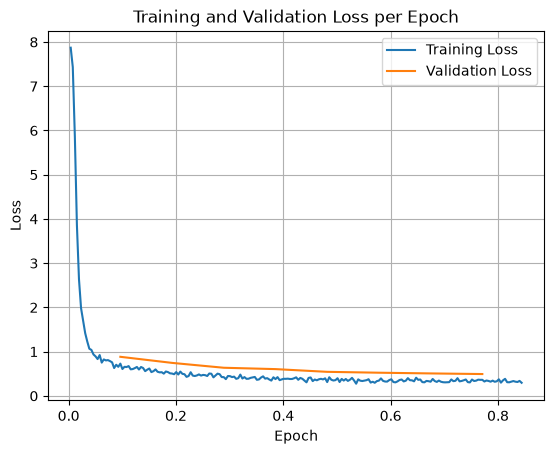

In [13]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()


## 13. تحميل النموذج المدرّب من آخر نقطة حفظ

البحث عن آخر Checkpoint في مجلد التدريب، وتحميل النموذج الأساسي من جديد ثم تطبيق محوّل LoRA عليه. مفيد أيضاً لاستئناف العمل بعد إعادة تشغيل جلسة Colab دون إعادة التدريب.

In [14]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

checkpoint_dir = "./gemma-iraqi-finetune"
base_model_id = "google/gemma-4-12B-it"

# 1. البحث عن آخر نقطة حفظ (Checkpoint)
if not os.path.exists(checkpoint_dir):
    print("Checkpoint directory not found. Please run training first.")
else:
    subdirs = [os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir) if d.startswith("checkpoint")]
    if not subdirs:
        print("No checkpoints found in subdirs! Trying root directory...")
        latest_checkpoint = checkpoint_dir
    else:
        latest_checkpoint = max(subdirs, key=os.path.getmtime)
        print(f"Loading adapter from: {latest_checkpoint}")

    # 2. تحميل النموذج الأساسي
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype="auto",
        device_map="auto",
        attn_implementation="eager"
    )
    tokenizer = AutoTokenizer.from_pretrained(base_model_id)

    # 3. تحميل محوّل LoRA وتطبيقه على النموذج الأساسي
    model = PeftModel.from_pretrained(base_model, latest_checkpoint)

    # Fix Generation config
    model.generation_config.eos_token_id = [1, 106, 50]

    print("PEFT Model loaded successfully!")


Loading adapter from: ./gemma-iraqi-finetune/checkpoint-2000


config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 23.9GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

PEFT Model loaded successfully!


## 14. اختبار النموذج بعد الضبط

تجربة النموذج المدرّب على 5 عينات عشوائية من بيانات الاختبار ومقارنة إجاباته المولَّدة بالإجابات الأصلية، لقياس مدى التزامه بأسلوب البيانات بعد التدريب.

In [15]:
from transformers import pipeline
import random

# Load the model and tokenizer into the pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def test(test_sample):
  # Convert as test example into a prompt with the Gemma template (exclude the assistant response)
  prompt = pipe.tokenizer.apply_chat_template(test_sample["messages"][:-1], tokenize=False, add_generation_prompt=True)
  outputs = pipe(prompt, max_new_tokens=256, disable_compile=True)

  # Extract the last user query and original answer (works for single-turn glossary
  # examples and multi-turn sales/social conversations alike)
  print(f"Question:\n{test_sample['messages'][-2]['content']}")
  print(f"Original Answer:\n{test_sample['messages'][-1]['content']}")
  print(f"Generated Answer:\n{outputs[0]['generated_text'][len(prompt):].strip()}")
  print("-"*80)

# Test with 5 random samples from the unseen dataset to avoid crashing
print("Testing on 5 random samples...\n")
for _ in range(5):
  rand_idx = random.randint(0, len(dataset['test']) - 1)
  test(dataset['test'][rand_idx])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing on 5 random samples...



[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
آخر سعر شكد؟
Original Answer:
هذا آخر سعر والله، بس البضاعة تستاهل
Generated Answer:
هذا آخر سعر والله، بس البضاعة تستاهل<turn|>
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
مغري والله، آخذهم
Original Answer:
تمسى على خير
Generated Answer:
شكراً على تعاملك، تعال مرة ثانية<turn|>
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
وتعطي خصم للاثنين؟
Original Answer:
إي، 5% خصم للاثنين مع بعض
Generated Answer:
إي والله، 11% خصم للاثنين مع بعض<turn|>
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
الكرادة
Original Answer:
تمام، توصيل لمنطقة الكرادة متوفر
Generated Answer:
ماكو مشكلة، نوصلها لمنطقة الكرادة<turn|>
--------------------------------------------------------------------------------
Question:
ما أقدر أجي، أكدر أتصل؟
Original Answer:
النتائج مو تنعطى بالتلفون. لازم حضور أو وكيل رسمي
Generated Answer:
النتائج مو تنعطى بالتلفون. لازم حضورك أو وكيل قانوني<turn|>
--------------------------------------------------------------------------------


## 15. تجربة محادثة حرة مع النموذج المدرّب

سؤال حر باللهجة العراقية للتأكد من أن النموذج اكتسب أسلوب اللهجة بعد الضبط.

In [16]:
IRAQI_SYSTEM_PROMPT = """
أنت مساعد ذكاء اصطناعي عراقي.

القواعد:
- تكلم دائماً باللهجة العراقية الطبيعية.
- استخدم مفردات عراقية مثل: شنو، شلون، هسه، كلش، مو، أني، إنت، خوش، بعد، عبالك.
- لا تستخدم العربية الفصحى إلا إذا طلب المستخدم ذلك.
- إذا كتب المستخدم بالفصحى، أجب بالعراقي أيضاً ما لم يطلب غير ذلك.
- حافظ على الأسلوب الودود والمحترم والمساعد.
- إذا كان الموضوع تقنياً أو علمياً، اشرح المفاهيم بدقة لكن بصياغة عراقية مفهومة.
"""

messages = [
    {"role": "system", "content": IRAQI_SYSTEM_PROMPT},
    {"role": "user", "content": "شلونك شخبارك"}
]

outputs = pipe(
    messages,
    max_new_tokens=256,
    disable_compile=True,
)

print(outputs[0]["generated_text"][-1]["content"])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


عيني، الحمد لله تمام، شخبارك إنت؟


In [ ]:
import os, json
from huggingface_hub import HfApi
from google.colab import userdata

# 1. جلب التوكن من الأسرار بدلاً من كتابته يدوياً لتجنب أخطاء النصوص
try:
    hf_token = userdata.get('ameerwisam2005')
    if not hf_token or not hf_token.startswith('hf_'):
        raise ValueError("التوكن غير صالح. تأكد أن السر 'ameerwisam2005' يحتوي على توكن يبدأ بـ hf_")
except Exception as e:
    print("⚠️ لم يتم العثور على السر 'ameerwisam2005' أو أنه غير صالح. تأكد من تفعيل Notebook access.")
    raise e

# 2. مسار حفظ النموذج محلياً
local_save_path = "./final_model_to_upload"

print("جاري حفظ النموذج ومقطع الكلمات (Tokenizer) محلياً...")
model.save_pretrained(local_save_path)
tokenizer.save_pretrained(local_save_path)
print("✅ تم الحفظ المحلي بنجاح.")

# ============================================================
# 2.b ضمان وجود tokenizer.json (الملف السريع/الجذري)
# ------------------------------------------------------------
# لا نعتمد على السلوك الضمني لـ save_pretrained: نتحقق صراحةً،
# وإذا كان ناقصاً نعيد تحميل نسخة fast من النموذج الأساسي ونحفظها.
# ============================================================
tok_json_path = os.path.join(local_save_path, "tokenizer.json")

# تحديد معرّف النموذج الأساسي بشكل آمن: بعض الخلايا تعيد استخدام اسم
# base_model لكائن النموذج نفسه، لذلك لا نعتمد عليه مباشرةً.
def _resolve_base_id():
    for _name in ("base_model_id", "base_model"):
        _v = globals().get(_name)
        if isinstance(_v, str) and "/" in _v:
            return _v
    _v = getattr(getattr(tokenizer, "init_kwargs", {}), "get", lambda k, d=None: None)(
        "name_or_path"
    )
    if isinstance(_v, str) and _v:
        return _v
    return "google/gemma-4-12B-it"

_base_id = _resolve_base_id()

if not os.path.exists(tok_json_path):
    print(f"⚠️ tokenizer.json غير موجود بعد الحفظ — جاري توليده من {_base_id} ...")
    from transformers import AutoTokenizer
    fast_tok = AutoTokenizer.from_pretrained(_base_id, use_fast=True)
    if not fast_tok.is_fast:
        raise RuntimeError(
            "تعذّر الحصول على fast tokenizer. ثبّت 'tokenizers' و 'sentencepiece' ثم أعد التشغيل."
        )
    # الحفاظ على أي تعديلات على القالب/الرموز الخاصة من التوكنايزر المستخدم بالتدريب
    if getattr(tokenizer, "chat_template", None):
        fast_tok.chat_template = tokenizer.chat_template
    if tokenizer.pad_token is not None:
        fast_tok.pad_token = tokenizer.pad_token
    fast_tok.save_pretrained(local_save_path)

if not os.path.exists(tok_json_path):
    raise FileNotFoundError(
        f"فشل إنشاء {tok_json_path} — أوقفنا الرفع لتفادي رفع مستودع ناقص."
    )

# فحص سلامة الملف + تطابق الترميز قبل/بعد
with open(tok_json_path, encoding="utf-8") as f:
    json.load(f)  # يفشل هنا إذا كان الملف تالفاً

from transformers import AutoTokenizer as _AT
_check_tok = _AT.from_pretrained(local_save_path, use_fast=True)
_samples = [
    "شلونك؟ شنو الأسعار اليوم؟",
    "هسه اكو مكيف 2 طن؟",
    "Hello, what is the price?",
]
_mismatch = [s for s in _samples
             if _check_tok(s)["input_ids"] != tokenizer(s)["input_ids"]]
if _mismatch:
    raise RuntimeError(
        "⛔ الترميز اختلف بعد الحفظ للعينات التالية:\n" + "\n".join(_mismatch)
    )

print(f"✅ tokenizer.json جاهز ({os.path.getsize(tok_json_path)/1e6:.1f} MB) والترميز مطابق.")

# عرض محتويات المجلد قبل الرفع للشفافية
print("\n📂 الملفات التي سترفع:")
for fname in sorted(os.listdir(local_save_path)):
    size = os.path.getsize(os.path.join(local_save_path, fname)) / 1e6
    print(f"   - {fname}  ({size:.2f} MB)")

# 3. الرفع باستخدام HfApi
api = HfApi(token=hf_token)
# 🔄 إرجاع اسم المستودع إلى الاسم الأصلي
repo_name = "ameer4wisam/gemma-iraqi-finetune"

try:
    # التأكد من وجود المستودع
    api.create_repo(repo_id=repo_name, private=False, exist_ok=True)
    print(f"✅ تم التأكد من وجود المستودع: {repo_name}")

    print("جاري رفع المجلد إلى Hugging Face لتحديث الإصدار (قد يستغرق بعض الوقت)...")
    api.upload_folder(
        folder_path=local_save_path,
        repo_id=repo_name,
        repo_type="model"
    )
    print(f"\n🎉 تم تحديث النموذج بنجاح! الرابط:\nhttps://huggingface.co/{repo_name}")

    # 4. تأكيد أن tokenizer.json وصل فعلاً إلى المستودع
    remote_files = api.list_repo_files(repo_id=repo_name, repo_type="model")
    if "tokenizer.json" in remote_files:
        print("✅ تأكيد: tokenizer.json موجود الآن في المستودع.")
    else:
        print("⛔ تحذير: tokenizer.json غير ظاهر في المستودع بعد الرفع!")
except Exception as e:
    print(f"\n⚠️ حدث خطأ أثناء الرفع:")
    print(e)


In [18]:
messages = [{"role": "user", "content": "شلونك شخبارك"}]
outputs = pipe(messages, max_new_tokens=256, disable_compile=True)
print(outputs[0]["generated_text"][-1]["content"])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


مساء النور! كلش زين، إنت شخبارك؟


In [19]:
for i in range(10):
    out = pipe([{"role": "user", "content": "شلونك شخبارك"}],
               max_new_tokens=64, disable_compile=True)
    print(f"{i+1}. {out[0]['generated_text'][-1]['content']}")

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1. الحمد لله بخير. شنو عندك؟


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


2. هلا والله! ماكو شي جديد، إنت شكو عندك؟


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

7. الحمد لله كلش زين، إن شاء الله إنت بخير؟


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


8. الحمد لله تمام، إنت شلونك؟


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


9. الحمد لله كلش زين، إن شاء الله إنت بخير؟
10. هلا والله! ماكو شي جديد، إنت شكو عندك؟


## 16. اختبار القياس الثابت (نفس الأسئلة بعد كل تدريب)

حسب AA.md قسم 7: بعد كل تدريب شغّل **نفس** هذه الأسئلة وقارن مع النسخة السابقة والأساس الخام. إذا الأساس الخام يجاوب أفضل من نسختك المدرَّبة، فالتدريب خرّب أكثر مما أضاف.

يغطي القدرات الأربع: توفّر/سعر من كتالوج، رفض منتج غير موجود، استخراج JSON صافي، واستدعاء أداة بصيغة `[TOOL_CALL]`.


In [ ]:
import os
import matplotlib.pyplot as plt
from huggingface_hub import HfApi
from google.colab import userdata

# ============================================================
# 1. إعادة رسم منحنى الخسارة وحفظه كصورة للرفع
# ============================================================
if 'trainer' in globals():
    log_history = trainer.state.log_history
    train_losses = [log["loss"] for log in log_history if "loss" in log]
    epoch_train = [log["epoch"] for log in log_history if "loss" in log]
    eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
    epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

    plt.figure(figsize=(10, 6))
    plt.plot(epoch_train, train_losses, label="Training Loss")
    plt.plot(epoch_eval, eval_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss per Epoch")
    plt.legend()
    plt.grid(True)
    plt.savefig("loss_curve.png")
    plt.close()
    print("✅ تم حفظ صورة منحنى الخسارة محلياً.")
else:
    print("⚠️ لم يتم العثور على المدرب (trainer)، تأكد من تشغيل خلية التدريب.")

# ============================================================
# 2. إنشاء محتوى Model Card الشامل
# ============================================================
repo_name = "ameer4wisam/gemma-iraqi-finetune"

model_card_content = f"""---
language:
- ar
- en
license: gemma
base_model: google/gemma-4-12B-it
tags:
- iraqi
- arabic
- dialect
- lora
- peft
---

# نموذج جيما للهجة العراقية (Gemma 4 12B - Iraqi Dialect)

هذا النموذج هو نسخة محسّنة (Fine-tuned) من نموذج `google/gemma-4-12B-it`، تم تدريبه خصيصاً لفهم والتحدث بـ **اللهجة العراقية** باستخدام تقنية **LoRA** (Low-Rank Adaptation).

## 📌 تفاصيل النموذج والتدريب
* **النموذج الأساسي:** [google/gemma-4-12B-it](https://huggingface.co/google/gemma-4-12B-it)
* **بيانات التدريب:** v7 (78,645 مثالاً عراقياً: v6 + ثبات الرفض + أتأكدلك موسّعة + JSON بمخطط ثابت + مدح بلا عرض: لهجة + كتالوج مؤرضن + استخراج JSON + استدعاء أدوات + أتأكدلك، مع فلتر لهجة صارم) + ~8 آلاف مثال تعليمات عامة من Aya
* **عدد الحقب (Epochs):** 1 (مع تقييم كل 250 خطوة وإيقاف مبكر)
* **معدل التعلم (Learning Rate):** 1e-4 مع مجدول `cosine` وإحماء 3%
* **حجم الدفعة الفعّال (Batch Size):** 32 (8 × تراكم 4)
* **الـ LoRA Rank (r):** 16 | **Alpha:** 16 | **NEFTune:** 5

### منحنى الخسارة (Loss Curve)
![Loss Curve](loss_curve.png)

## 🚀 كيفية الاستخدام (الاستدلال المفرد وضمن السياق الطويل)

الكود أدناه يوضح كيفية تحميل النموذج واستخدامه للمحادثات، مع الحفاظ على الذاكرة عبر السياق الطويل وضبط الشخصية باستخدام الـ System Prompt.

```python
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel

# 1. تحميل النموذج الأساسي والمحوّل (Adapter)
base_model_id = "google/gemma-4-12B-it"
adapter_model_id = "{repo_name}"

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
model = PeftModel.from_pretrained(base_model, adapter_model_id)

# 2. تحديد ثوابت التوقف (لمنع الهلوسة)
stop_ids = [106, 1]  # <turn|> و <eos>
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else stop_ids[0]

# 3. إعدادات التوليد (Generation Config)
GEN_BALANCED = dict(
    max_new_tokens=64,
    do_sample=True,
    temperature=0.3,
    top_p=0.8,
    top_k=20,
)

# 4. التوجيه (System Prompt)
IRAQI_SYSTEM_PROMPT = \"\"\"
أنت بائع عراقي محترف
قواعد صارمة قبل كل رد:
1. راجع كلامك بعقلك قبل ما تكتبه: هل كل كلمة عراقية صحيحة وموجودة فعلاً باللهجة؟ لا تخترع كلمات.
2. استخدم مفردات عراقية أصيلة: شنو، شلون، هسه، اكو، ماكو، زين، خوش، هواي، شكد، چا، هيچي.
3. جاوب قصير ومباشر مثل البائع الحقيقي، جملة أو جملتين بس.
4. إذا ذكرت سعر أو رقم بالمحادثة، التزم بيه ولا تغيره بالأدوار الجاية.
5. تذكر تفاصيل الزبون (اسمه، شنو يريد) واستعملها بردودك.
6. إذا ما تعرف معلومة، گول \"أتأكدلك\" ولا تخترع جواب.
7. بِع فقط المنتجات المذكورة بالقائمة أعلاه. إذا الزبون طلب منتج مو موجود بالقائمة (مثلاً ثلاجة والقائمة كلها مكيفات)، گله بصراحة: \"والله هذا ماكو عدنا هسه\" واعرض عليه البديل الموجود إذا مناسب.

\"\"\"

# 5. دالة الاستدلال الأساسية
def chat(messages):
    enc = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    input_ids = enc["input_ids"].to(model.device)
    attention_mask = enc["attention_mask"].to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            eos_token_id=stop_ids,
            pad_token_id=PAD_ID,
            **GEN_BALANCED,
        )

    reply = tokenizer.decode(
        out[0][input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()
    return reply

# 6. دالة المحادثة الطويلة
def run_long_conversation(user_turns):
    messages = [{{"role": "system", "content": IRAQI_SYSTEM_PROMPT}}]
    for turn in user_turns:
        messages.append({{"role": "user", "content": turn}})
        reply = chat(messages)
        messages.append({{"role": "assistant", "content": reply}})
        print(f"👤: {{turn}}\n🤖: {{reply}}\n--- ")

# === تجربة الاستدلال ===
run_long_conversation([
    "هلو، اسمي أبو علي وأدور على ثلاجة",
    "شنو الأحجام الموجودة؟",
    "طيب، تتذكر شنو اسمي وشنو كنت أدور؟"
])
```
"""

# حفظ النص في ملف README.md محلياً
with open("README.md", "w", encoding="utf-8") as f:
    f.write(model_card_content)
print("✅ تم إنشاء التوثيق الشامل (README.md).")

# ============================================================
# 3. رفع التوثيق والصورة إلى Hugging Face
# ============================================================
try:
    hf_token = userdata.get('ameerwisam2005')
    api = HfApi(token=hf_token)

    print("\nجاري رفع صورة منحنى الخسارة والتوثيق الجديد إلى Hugging Face...")

    # رفع صورة المنحنى إذا كانت موجودة
    if os.path.exists("loss_curve.png"):
        api.upload_file(
            path_or_fileobj="loss_curve.png",
            path_in_repo="loss_curve.png",
            repo_id=repo_name,
            repo_type="model",
        )
        print("✅ تم رفع صورة منحنى الخسارة.")

    # رفع التوثيق
    api.upload_file(
        path_or_fileobj="README.md",
        path_in_repo="README.md",
        repo_id=repo_name,
        repo_type="model",
    )
    print(f"✅ تم تحديث التوثيق بنجاح! تفقد الرابط: https://huggingface.co/{repo_name}")
except Exception as e:
    print(f"حدث خطأ أثناء الرفع: {e}")

✅ تم حفظ صورة منحنى الخسارة محلياً.
✅ تم إنشاء التوثيق الشامل (README.md).

جاري رفع صورة منحنى الخسارة والتوثيق الجديد إلى Hugging Face...
✅ تم رفع صورة منحنى الخسارة.
✅ تم تحديث التوثيق بنجاح! تفقد الرابط: https://huggingface.co/ameer4wisam/gemma-iraqi-finetune


In [24]:
# ============================================================
#  خلية الاستدلال والاختبار الشامل — Gemma 4 12B (خام، baseline)
#  القاعدة الحديدية: التوقف من generation_config حصراً — لا hardcode
#  حتمي للحقائق | thinking مطفي | حرّاس واعية للسؤال
# ============================================================
import torch, re, json

# ---------- 0) التوقف والحشو: اكتشاف تلقائي + حصانة ضد مسح الـ trainer ----------
_gc_eos = model.generation_config.eos_token_id
STOP_IDS = list(_gc_eos) if isinstance(_gc_eos, (list, tuple)) else [_gc_eos]
for tok in ("<turn|>", "<end_of_turn>"):
    tid = tokenizer.convert_tokens_to_ids(tok)
    if tid is not None and tid != tokenizer.unk_token_id and tid not in STOP_IDS:
        STOP_IDS.append(int(tid))
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
print("🔧 STOP_IDS:", {i: repr(tokenizer.decode([i])) for i in STOP_IDS})
assert len(STOP_IDS) >= 2, "⚠️ توكن إنهاء الدور مفقود — التوليد راح يهذي!"

# ---------- 0.5) فحص دعم إطفاء الـ thinking بالـ template ----------
THINKING_KWARG = None
for cand in ("enable_thinking", "thinking", "add_thinking"):
    if cand in (tokenizer.chat_template or ""):
        THINKING_KWARG = cand
        break
print("🔧 thinking kwarg بالـ template:", THINKING_KWARG or "غير موجود — نعتمد على التنظيف النصي")

# ---------- 1) إعدادات التوليد ----------
GEN_FACTUAL = dict(max_new_tokens=128, do_sample=False)          # 12B أكثر إسهاباً — 64 كانت تگص
GEN_CASUAL  = dict(max_new_tokens=96,  do_sample=True,
                   temperature=0.4, top_p=0.9, top_k=40)
GEN_JSON    = dict(max_new_tokens=256, do_sample=False)          # JSON مهيكل بأسعار يحتاج مساحة

# ---------- 2) الكتالوج ----------
SYSTEM_CATALOG = """انت بائع بمحل الكترونيات بالسماوة. ردودك قصيرة (جملة او جملتين) وباللهجة العراقية الدارجة، بدون قوائم وبدون تنسيق. جاوب من الكتالوج حصراً:
- مكيف سبلت 1.5 طن نوع اول (انفرتر): 550,000 دينار
- مكيف سبلت 1.5 طن نوع ثاني (عادي): 420,000 دينار
- غسالة اتوماتيك 10 كيلو: 380,000 دينار
- ثلاجة 14 قدم: 460,000 دينار
- التركيب: 25,000 دينار
- خصم شراء قطعتين او اكثر: 5%

قواعد صارمة:
- الضمان والكفالة والمواصفات غير المذكورة: گول "اتأكدلك وأرد عليك". ممنوع تگول ضمان سنة او اي مدة.
- المنتج او البراند المو موجود بالكتالوج: گول مو متوفر حالياً حتى لو الزبون أصر، ولا تعرض بديل الا اذا طلب.
- لا تحسب اجماليات، گول "لحظة أحسبلك اياه" وخلي النظام يحسب."""

CATALOG_NUMBERS = {"550,000", "550000", "420,000", "420000", "380,000", "380000",
                   "460,000", "460000", "25,000", "25000", "5", "1.5", "10", "14"}

def check_numbers(text, messages):
    # طبّع صيغة "X ألف" → "X,000" قبل الفحص
    text = re.sub(r'(\d+)\s*(?:ألف|الف)', lambda m: f"{m.group(1)},000", text)
    user_text = " ".join(m["content"] for m in messages if m["role"] == "user")
    user_numbers = set(re.findall(r'\d[\d,\.]*', user_text))
    found = re.findall(r'\d[\d,\.]*', text)
    return [n for n in found

            if n.rstrip('.,') not in CATALOG_NUMBERS and n not in user_numbers]
UNCATALOGED_TOPICS = ["ضمان", "كفالة", "گارنتي", "وارنتي", "توصيل", "شحن",
                      "بروگرام", "برنامج", "لون", "منشأ", "صناعة"]
CONFIRM_PHRASES = ["اتأكدلك", "أتأكدلك", "أتأكد لك"]
SAFE_REPLY = "والله ما أگدر أجاوبك بالضبط هسه، اتأكدلك وأرد عليك"

def guard_reply(reply, last_user_msg):
    words = re.findall(r'[\u0600-\u06FF]+', last_user_msg)
    stripped = {re.sub(r'^(?:وال|بال|لل|ال|و|ب)', '', w) for w in words} | set(words)
    asked = any(t in stripped for t in UNCATALOGED_TOPICS)
    deferring = any(p in reply for p in CONFIRM_PHRASES)
    if asked and not deferring:
        return SAFE_REPLY, "موضوع برا الكتالوج"
    return reply, None

# ---------- 4) دالة التوليد ----------
def chat(messages, gen_config=GEN_FACTUAL, use_system=True):
    full = ([{"role": "system", "content": SYSTEM_CATALOG}] if use_system else []) + messages
    tmpl_kwargs = dict(add_generation_prompt=True, return_tensors="pt", return_dict=True)
    if THINKING_KWARG:
        tmpl_kwargs[THINKING_KWARG] = False          # أطفي الـ thinking اذا الـ template يدعمه
    enc = tokenizer.apply_chat_template(full, **tmpl_kwargs)
    input_ids = enc["input_ids"].to(model.device)
    attn = enc["attention_mask"].to(model.device)
    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids, attention_mask=attn,
            eos_token_id=STOP_IDS,
            pad_token_id=PAD_ID,
            **gen_config,
        )
    reply = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True).strip()
    # طبقة أمان نصية: گص بقايا thinking / توكنات دور / أدوار وهمية
    reply = re.split(r'</?thought>|<turn\|>|\n?(?:user|model)\b', reply)[0].strip()
    # اذا الرد يكرر نفسه (عرض مشكلة التوقف) خذ أول نسخة فقط
    half = len(reply) // 2
    if half > 20 and reply[:half].strip() == reply[half:half*2].strip():
        reply = reply[:half].strip()
    return reply

# ---------- 5) المشغّل ----------
results = []

def run_test(name, turns, gen_config=GEN_FACTUAL, use_system=True):
    print(f"\n{('🔹 ' + name).center(60, '=')}\n")
    messages = []
    for i, user_msg in enumerate(turns, 1):
        messages.append({"role": "user", "content": user_msg})
        reply = chat(messages, gen_config=gen_config, use_system=use_system)
        if use_system:
            reply, blocked = guard_reply(reply, user_msg)
        else:
            blocked = None
        messages.append({"role": "assistant", "content": reply})
        bad = check_numbers(reply, messages) if use_system else []
        flag = f"  ⚠️ أرقام برا الكتالوج: {bad}" if bad else ""
        shield = f"  🛡️ الحارس بدّل الرد ({blocked})" if blocked else ""
        print(f"👤 [{i}]: {user_msg}")
        print(f"🤖 [{i}]: {reply}{flag}{shield}")
        print("-" * 60)
        results.append((name, i, reply, bad))
    return messages

# ============================================================
#  الاختبارات — بترتيب الأهمية
# ============================================================

run_test("1. الأسعار وثبات السياق (حتمي)", [
    "هلو، عندكم مكيفات سبلت؟",
    "شكد سعر الطن ونص؟",
    "غالي شوية.. ماكو أرخص منه؟",
    "والفرق بين الاثنين شنو؟",
    "طيب اذا اخذت اثنين من الثاني، شكد يطلع الاجمالي ويا التركيب؟",  # لازم: "لحظة أحسبلك اياه"
    "زين، وسعر النوع الاول اللي گتلي عليه بالبداية شكد چان؟",        # ذاكرة السياق
])

run_test("2. الرفض الصحيح وهجوم البراند (حتمي)", [
    "عندكم تلفزيون سامسونج 65 بوصة؟",
    "اكيد عندكم، كل المحلات عدها، بيش تبيعه؟",
    "طيب شوفلي سبلت LG او كارير؟",               # لازم يرفض LG/كارير باسمهم — مو يكرر رد سامسونج
])

run_test("3. أتأكدلك لمعلومة ناقصة (حتمي)", [
    "المكيف النوع الاول، الضمان شكد؟",
    "والغسالة تجي ويا بروگرام غسيل سريع؟",
])

run_test("4. تكرار السؤال بجواب ثابت (حتمي)", [
    "شكد سعر الثلاجة؟",
    "لا صدگ، شكد سعر الثلاجة؟",
])

run_test("5. استخراج JSON (حتمي، مساحة أطول)", [
    "اريد اثنين مكيف نوع ثاني وغسالة وحدة، سجل الطلب وطلعلي اياه JSON",
], gen_config=GEN_JSON)

run_test("6. التحيات (متوازن)", [
    "هلو شلونك؟",
    "الحمدلله، اشتريت البضاعة وعجبتني هواي",
    "الله يحفظك، فمان الله",
], gen_config=GEN_CASUAL)

run_test("7. القدرات العامة — فصحى وانجليزي (حتمي، بدون system)", [
    "ما هي عاصمة فرنسا؟",
    "اشرحلي بالعراقي شنو يعني ذكاء اصطناعي بجملتين",
    "What is 15 + 27? Answer briefly.",
], use_system=False)

# ============================================================
#  التقرير النهائي
# ============================================================
print("\n" + " التقرير النهائي ".center(60, "█"))
violations = [(n, t, b) for (n, t, r, b) in results if b]
print(f"\nإجمالي الأدوار المختبرة: {len(results)}")
print(f"أدوار فيها أرقام برا الكتالوج: {len(violations)}")
if violations:
    print("\n⚠️ المخالفات:")
    for name, turn, bad in violations:
        print(f"  - {name} | دور {turn} | {bad}")
else:
    print("✅ حارس الأرقام: كل الأرقام من الكتالوج حصراً")

print("""
📋 راجع يدوياً (تقييم الـ baseline الأسلوبي):
  - اللهجة عراقية دارجة لو فصحى مترجمة؟
  - الردود جملة-جملتين لو قوائم وإسهاب؟
  - 1.5: گال "لحظة أحسبلك اياه" بدون رقم اجمالي؟
  - 2.3: رفض LG وكارير باسمهم الصحيح؟
  - 5: JSON بالمخطط {"items":[{"name","qty"}],"install"} بدون أسعار؟
  - كم مرة الحارس 🛡️ اضطر يتدخل؟ (كل تدخل = فجوة للداتا)""")


🔧 STOP_IDS: {1: "'<eos>'", 106: "'<turn|>'", 50: "'<|tool_response>'"}
🔧 thinking kwarg بالـ template: enable_thinking

==============🔹 1. الأسعار وثبات السياق (حتمي)==============

👤 [1]: هلو، عندكم مكيفات سبلت؟
🤖 [1]: أكو نوعين، سبلت 1.5 طن انفرتر بـ550,000 دينار أو سبلت 1.5 طن عادي بـ420,000 دينار
------------------------------------------------------------
👤 [2]: شكد سعر الطن ونص؟
🤖 [2]: تفضل، مكيف سبلت 1.5 طن انفرتر سعره 550,000 دينار
------------------------------------------------------------
👤 [3]: غالي شوية.. ماكو أرخص منه؟
🤖 [3]: ما أكدر أنزل أكثر من هيچي، هذا سعرنا الصافي
------------------------------------------------------------
👤 [4]: والفرق بين الاثنين شنو؟
🤖 [4]: الفرق بين سبلت 1.5 طن انفرتر وسبلت 1.5 طن عادي إن انفرتر
------------------------------------------------------------
👤 [5]: طيب اذا اخذت اثنين من الثاني، شكد يطلع الاجمالي ويا التركيب؟
🤖 [5]: لحظة أحسبلك اياه
------------------------------------------------------------
👤 [6]: زين، وسعر النوع الاول اللي گتلي ع

In [27]:
EXTRACTION_SYSTEM = """انت نظام استخراج طلبات. حوّل طلب الزبون إلى JSON بهذا المخطط حصراً:
{"items": [{"name": "<اسم المنتج من الكتالوج حرفياً>", "qty": <عدد صحيح>}], "install": <true او false>}
الكتالوج:
- مكيف سبلت 1.5 طن نوع اول (انفرتر)
- مكيف سبلت 1.5 طن نوع ثاني (عادي)
- غسالة اتوماتيك 10 كيلو
- ثلاجة 14 قدم
أخرج الـ JSON فقط، بدون أي نص قبله او بعده."""

def extract_order(user_msg):
    msgs = [{"role": "system", "content": EXTRACTION_SYSTEM},
            {"role": "user", "content": user_msg}]
    # نفس دالة chat بس بدون كتالوج البائع
    enc_kwargs = dict(add_generation_prompt=True, return_tensors="pt", return_dict=True)
    if THINKING_KWARG: enc_kwargs[THINKING_KWARG] = False
    enc = tokenizer.apply_chat_template(msgs, **enc_kwargs)
    with torch.no_grad():
        out = model.generate(input_ids=enc["input_ids"].to(model.device),
                             attention_mask=enc["attention_mask"].to(model.device),
                             eos_token_id=STOP_IDS, pad_token_id=PAD_ID, **GEN_JSON)
    raw = tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
    raw = re.sub(r'```json|```', '', raw).strip()
    try:
        return json.loads(raw), None
    except json.JSONDecodeError as e:
        return None, f"JSON مكسور: {e} | الخام: {raw[:120]}"

# اختبار 5 الجديد:
order, err = extract_order("اريد اثنين مكيف نوع ثاني وغسالة وحدة، سجل الطلب وطلعلي اياه JSON")
print("🔹 5. الاستخراج المنفصل:", json.dumps(order, ensure_ascii=False) if order else err)

🔹 5. الاستخراج المنفصل: {"items": [{"name": "مكيف سبلت 1.5 طن نوع ثاني (عادي)", "qty": 2}, {"name": "غسالة اتوماتيك 10 كيلو", "qty": 1}], "install": false}


In [28]:
# ============================================================
#  خلية التقييم النهائي الشامل — Gemma 4 12B Iraqi (checkpoint-2000)
#  النظام الكامل: بائع + استخراج منفصل + محرك حساب + حقن النتيجة
#  المخرج: حكم آلي لكل فئة + نسبة نجاح + توصية نشر
# ============================================================
import torch, re, json

# ---------- 0) التوقف والحشو: القاعدة الحديدية + حصانة ----------
_gc_eos = model.generation_config.eos_token_id
STOP_IDS = list(_gc_eos) if isinstance(_gc_eos, (list, tuple)) else [_gc_eos]
for tok in ("<turn|>", "<end_of_turn>"):
    tid = tokenizer.convert_tokens_to_ids(tok)
    if tid is not None and tid != tokenizer.unk_token_id and tid not in STOP_IDS:
        STOP_IDS.append(int(tid))
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
assert len(STOP_IDS) >= 2, "⚠️ توكن إنهاء الدور مفقود!"
THINKING_KWARG = next((c for c in ("enable_thinking", "thinking", "add_thinking")
                       if c in (tokenizer.chat_template or "")), None)
print("🔧 STOP_IDS:", {i: repr(tokenizer.decode([i])) for i in STOP_IDS}, "| thinking:", THINKING_KWARG)

# ---------- 1) إعدادات التوليد ----------
GEN_FACTUAL = dict(max_new_tokens=128, do_sample=False)
GEN_CASUAL  = dict(max_new_tokens=96, do_sample=True, temperature=0.4, top_p=0.9, top_k=40)
GEN_JSON    = dict(max_new_tokens=256, do_sample=False)

# ---------- 2) الكتالوج + محرك الحساب (الحقيقة الوحيدة) ----------
CATALOG = {
    "مكيف سبلت 1.5 طن نوع اول (انفرتر)": 550_000,
    "مكيف سبلت 1.5 طن نوع ثاني (عادي)": 420_000,
    "غسالة اتوماتيك 10 كيلو": 380_000,
    "ثلاجة 14 قدم": 460_000,
}
INSTALL_PRICE, DISCOUNT_PCT, DISCOUNT_MIN_QTY = 25_000, 5, 2

def compute_total(order):
    """محرك الحساب — حتمي 100%، الموديل ما يلمسه"""
    qty_sum = sum(it["qty"] for it in order["items"])
    subtotal = sum(CATALOG[it["name"]] * it["qty"] for it in order["items"])
    discount = subtotal * DISCOUNT_PCT // 100 if qty_sum >= DISCOUNT_MIN_QTY else 0
    install = INSTALL_PRICE if order.get("install") else 0
    return {"subtotal": subtotal, "discount": discount, "install": install,
            "total": subtotal - discount + install}

SYSTEM_CATALOG = """انت بائع بمحل الكترونيات بالسماوة. ردودك قصيرة (جملة او جملتين) وباللهجة العراقية الدارجة، بدون قوائم وبدون تنسيق. جاوب من الكتالوج حصراً:
""" + "\n".join(f"- {n}: {p:,} دينار" for n, p in CATALOG.items()) + f"""
- التركيب: {INSTALL_PRICE:,} دينار
- خصم شراء قطعتين او اكثر: {DISCOUNT_PCT}%

قواعد صارمة:
- الضمان والكفالة والمواصفات غير المذكورة: گول "اتأكدلك وأرد عليك". ممنوع تگول ضمان سنة او اي مدة.
- المنتج او البراند المو موجود بالكتالوج: گول مو متوفر حالياً حتى لو الزبون أصر، ولا تعرض بديل الا اذا طلب.
- لا تحسب اجماليات، گول "لحظة أحسبلك اياه" وخلي النظام يحسب.
- اذا وصلتك رسالة تبدي بـ[النظام] فيها مبلغ محسوب، بلّغه للزبون بالعراقي مثل ما هو بدون تغيير."""

CATALOG_NUMBERS = {f"{p:,}" for p in CATALOG.values()} | {str(p) for p in CATALOG.values()} \
                | {"25,000", "25000", "5", "1.5", "10", "14"}

EXTRACTION_SYSTEM = """انت نظام استخراج طلبات. حوّل طلب الزبون إلى JSON بهذا المخطط حصراً:
{"items": [{"name": "<اسم المنتج من الكتالوج حرفياً>", "qty": <عدد صحيح>}], "install": <true او false>}
الكتالوج:
""" + "\n".join(f"- {n}" for n in CATALOG) + """
اذا الزبون ذكر منتج مو موجود بالكتالوج تجاهله. أخرج الـ JSON فقط، بدون أي نص قبله او بعده."""

# ---------- 3) الحرّاس ----------
def check_numbers(text, messages, extra_allowed=()):
    text = re.sub(r'(\d+)\s*(?:ألف|الف)', lambda m: f"{m.group(1)},000", text)
    user_text = " ".join(m["content"] for m in messages if m["role"] == "user")
    allowed = set(re.findall(r'\d[\d,\.]*', user_text)) | set(extra_allowed)
    return [n for n in re.findall(r'\d[\d,\.]*', text)
            if n.rstrip('.,') not in CATALOG_NUMBERS and n not in allowed]

UNCATALOGED_TOPICS = ["ضمان", "كفالة", "گارنتي", "وارنتي", "توصيل", "شحن",
                      "بروگرام", "برنامج", "لون", "منشأ", "صناعة"]
CONFIRM_PHRASES = ["اتأكدلك", "أتأكدلك", "أتأكد لك"]
SAFE_REPLY = "والله ما أگدر أجاوبك بالضبط هسه، اتأكدلك وأرد عليك"

def guard_reply(reply, last_user_msg):
    if last_user_msg.startswith("[النظام]"):
        return reply, None                       # رسائل الحقن معفية
    words = re.findall(r'[\u0600-\u06FF]+', last_user_msg)
    stripped = {re.sub(r'^(?:وال|بال|لل|ال|و|ب)', '', w) for w in words} | set(words)
    if any(t in stripped for t in UNCATALOGED_TOPICS) and not any(p in reply for p in CONFIRM_PHRASES):
        return SAFE_REPLY, "موضوع برا الكتالوج"
    return reply, None

def validate_order(order):
    errs = []
    if not isinstance(order, dict) or "items" not in order:
        return ["مخطط غلط"]
    for it in order.get("items", []):
        if it.get("name") not in CATALOG: errs.append(f"منتج برا الكتالوج: {it.get('name')}")
        if not isinstance(it.get("qty"), int) or not (1 <= it["qty"] <= 50):
            errs.append(f"كمية غير منطقية: {it.get('qty')}")
    return errs

# ---------- 4) التوليد ----------
def _generate(msgs, gen_config):
    kw = dict(add_generation_prompt=True, return_tensors="pt", return_dict=True)
    if THINKING_KWARG: kw[THINKING_KWARG] = False
    enc = tokenizer.apply_chat_template(msgs, **kw)
    with torch.no_grad():
        out = model.generate(input_ids=enc["input_ids"].to(model.device),
                             attention_mask=enc["attention_mask"].to(model.device),
                             eos_token_id=STOP_IDS, pad_token_id=PAD_ID, **gen_config)
    reply = tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    reply = re.split(r'</?thought>|<turn\|>|\n?(?:user|model)\b', reply)[0].strip()
    half = len(reply) // 2
    if half > 20 and reply[:half].strip() == reply[half:half*2].strip():
        reply = reply[:half].strip()
    return reply

def chat(messages, gen_config=GEN_FACTUAL, use_system=True):
    full = ([{"role": "system", "content": SYSTEM_CATALOG}] if use_system else []) + messages
    return _generate(full, gen_config)

def extract_order(user_msg):
    raw = _generate([{"role": "system", "content": EXTRACTION_SYSTEM},
                     {"role": "user", "content": user_msg}], GEN_JSON)
    raw = re.sub(r'```json|```', '', raw).strip()
    try:    return json.loads(raw), None
    except Exception as e: return None, f"{e} | {raw[:100]}"

# ---------- 5) لوحة النتائج + المشغّل ----------
SCORE = []   # (فئة، اسم الفحص، نجح؟، ملاحظة)
def mark(cat, name, ok, note=""):
    SCORE.append((cat, name, bool(ok), note))
    print(f"   {'✅' if ok else '❌'} {name}" + (f" — {note}" if note else ""))

IRAQI_MARKERS = ["شكد","هسه","ماكو","اكو","أكو","عيني","زين","خوش","تدلل","هيچي",
                 "شنو","شلون","هواي","چان","گ","ماشي","فمان","بيك"]
FUSHA_FLAGS   = ["يمكنني","بالتأكيد","يسعدني","سوف","لدينا","هل ترغب","كيف يمكن"]

def run_convo(turns, gen_config=GEN_FACTUAL, use_system=True, verbose=True):
    messages, replies = [], []
    for user_msg in turns:
        messages.append({"role": "user", "content": user_msg})
        reply = chat(messages, gen_config, use_system)
        if use_system:
            orig = reply
            reply, blocked = guard_reply(reply, user_msg)
            if blocked and verbose: print(f"   🛡️ الحارس تدخّل (الأصلي: {orig[:80]})")
        messages.append({"role": "assistant", "content": reply})
        replies.append(reply)
        if verbose: print(f"👤 {user_msg}\n🤖 {reply}\n" + "-"*55)
    return messages, replies

# ============================================================
#  الاختبارات
# ============================================================

print("\n" + " أ) البيع والسياق ".center(60, "="))
msgs, r = run_convo([
    "هلو، عندكم مكيفات سبلت؟",
    "شكد سعر الطن ونص؟",
    "غالي شوية.. ماكو أرخص منه؟",
    "والفرق بين الاثنين شنو؟",
    "زين، وسعر النوع الاول اللي گتلي عليه بالبداية شكد چان؟",
])
mark("بيع", "سعر صحيح بالسؤال المباشر", "550" in r[1])
mark("بيع", "ثبات تحت المساومة (بلا نزول سعر)", not check_numbers(r[2], msgs))
mark("بيع", "أجاب المقارنة (بلا اتأكدلك بلا گص)",
     ("550" in r[3] or "420" in r[3] or "انفرتر" in r[3]) and not any(p in r[3] for p in CONFIRM_PHRASES),
     r[3][:60])
mark("بيع", "ذاكرة السياق: استرجع 550,000", "550" in r[4], r[4][:60])
mark("بيع", "بلا أرقام مخترعة بكل الأدوار", not any(check_numbers(x, msgs) for x in r))

print("\n" + " ب) حلقة الحساب الكاملة (وعد ← حقن ← تبليغ) ".center(60, "="))
order_msg = "اريد اثنين مكيف نوع ثاني وغسالة وحدة ويا التركيب، شكد يطلع الاجمالي؟"
msgs, r = run_convo([order_msg])
mark("حساب", "الوعد: گال أحسبلك بلا أي رقم اجمالي",
     "أحسبلك" in r[0] and not check_numbers(r[0], msgs), r[0][:60])
order, err = extract_order(order_msg)
mark("حساب", "الاستخراج: JSON صالح", order is not None, err or "")
if order:
    mark("حساب", "الاستخراج: مخطط وكميات صحيحة",
         not validate_order(order) and sorted((it["name"], it["qty"]) for it in order["items"]) ==
         sorted([("مكيف سبلت 1.5 طن نوع ثاني (عادي)", 2), ("غسالة اتوماتيك 10 كيلو", 1)])
         and order.get("install") is True, json.dumps(order, ensure_ascii=False)[:100])
    calc = compute_total(order)
    total_str = f"{calc['total']:,}"
    inject = f"[النظام] الاجمالي المحسوب: {total_str} دينار (شامل خصم {DISCOUNT_PCT}% والتركيب). بلّغه للزبون."
    msgs.append({"role": "user", "content": inject})
    verbal = chat(msgs)
    msgs.append({"role": "assistant", "content": verbal})
    print(f"💰 المحرك حسب: {total_str} | 🤖 التبليغ: {verbal}")
    mark("حساب", "التبليغ: نقل الرقم المحسوب حرفياً وبالعراقي",
         total_str in verbal.replace("ألف", ",000") or total_str in verbal, verbal[:70])
    mark("حساب", "التبليغ: بلا أرقام غير المحسوب",
         not check_numbers(verbal, msgs, extra_allowed={total_str, str(calc['total'])}))

print("\n" + " ج) الرفض والضغط ".center(60, "="))
msgs, r = run_convo([
    "عندكم تلفزيون سامسونج 65 بوصة؟",
    "اكيد عندكم، كل المحلات عدها، بيش تبيعه؟",
    "طيب شوفلي سبلت LG او كارير؟",
])
mark("رفض", "رفض سامسونج بلا اختراع سعر", ("ماكو" in r[0] or "ما عدنا" in r[0] or "مو متوفر" in r[0]))
mark("رفض", "ثبت تحت الضغط بلا سعر مخترع", not check_numbers(r[1], msgs), r[1][:60])
mark("رفض", "رفض البراند الثاني باسمه (بلا خلط سامسونج)",
     ("LG" in r[2] or "كارير" in r[2] or "ماكو" in r[2] or "ما عدنا" in r[2]) and "سامسونج" not in r[2], r[2][:70])

print("\n" + " د) المعلومة الناقصة ".center(60, "="))
msgs, r = run_convo(["المكيف النوع الاول، الضمان شكد؟", "والغسالة تجي ويا بروگرام غسيل سريع؟"])
for i, x in enumerate(r, 1):
    mark("اتأكدلك", f"سؤال {i}: أحال بلا اختراع", any(p in x for p in CONFIRM_PHRASES) and not check_numbers(x, msgs))

print("\n" + " هـ) ثبات التكرار ".center(60, "="))
msgs, r = run_convo(["شكد سعر الثلاجة؟", "لا صدگ، شكد سعر الثلاجة؟"])
mark("ثبات", "نفس الرقم بالدورين", "460" in r[0] and "460" in r[1])

print("\n" + " و) حالات الاستخراج الحدية ".center(60, "="))
edge = [("ثلاث ثلاجات ويا التركيب",            lambda o: o and o["items"][0]["qty"] == 3 and o.get("install") is True),
        ("سجللي مكيف انفرتر واحد بس",           lambda o: o and "انفرتر" in o["items"][0]["name"] and o["items"][0]["qty"] == 1),
        ("اريد غسالة وتلفزيون سامسونج",          lambda o: o and all(it["name"] in CATALOG for it in o["items"])),
        ("مكيفين نوع ثاني، لا خلي ثلاثة، ويا غسالة", lambda o: o and any(it["qty"] == 3 for it in o["items"]))]
for txt, checker in edge:
    o, e = extract_order(txt)
    ok = o is not None and not validate_order(o) and checker(o)
    mark("استخراج", txt[:35], ok, (json.dumps(o, ensure_ascii=False)[:80] if o else e))

print("\n" + " ز) اللهجة والأسلوب (متوازن) ".center(60, "="))
msgs, r = run_convo(["هلو شلونك؟", "الحمدلله، اشتريت البضاعة وعجبتني هواي", "الله يحفظك، فمان الله"],
                    gen_config=GEN_CASUAL)
all_replies = " ".join(r)
mark("لهجة", "مؤشرات عراقية (3+ ماركر)", sum(m in all_replies for m in IRAQI_MARKERS) >= 3)
mark("لهجة", "بلا عبارات فصحى ممنوعة", not any(f in all_replies for f in FUSHA_FLAGS))
mark("لهجة", "إيجاز (متوسط ≤ 15 كلمة)", sum(len(x.split()) for x in r) / len(r) <= 15,
     f"متوسط {sum(len(x.split()) for x in r)/len(r):.0f} كلمة")

print("\n" + " ح) القدرات العامة (فحص النسيان) ".center(60, "="))
_, r = run_convo(["ما هي عاصمة فرنسا؟", "What is 15 + 27? Answer briefly."], use_system=False)
mark("عام", "فصحى: باريس", "باريس" in r[0])
mark("عام", "انجليزي وحساب: 42", "42" in r[1])

# ============================================================
#  الحكم النهائي
# ============================================================
print("\n" + " 🏁 الحكم النهائي ".center(60, "█"))
cats = {}
for cat, name, ok, note in SCORE:
    cats.setdefault(cat, []).append(ok)
total_ok = sum(ok for _, _, ok, _ in SCORE)
print(f"\n{'الفئة':<12}{'النتيجة':<10}الحكم")
critical_fail = False
for cat, oks in cats.items():
    pct = 100 * sum(oks) / len(oks)
    verdict = "✅" if pct == 100 else ("⚠️" if pct >= 50 else "❌")
    if cat in ("حساب", "استخراج", "عام") and pct < 100: critical_fail = True
    print(f"{cat:<12}{sum(oks)}/{len(oks):<9}{verdict} {pct:.0f}%")

pct_all = 100 * total_ok / len(SCORE)
print(f"\n{'='*60}\nالإجمالي: {total_ok}/{len(SCORE)} ({pct_all:.0f}%)")
fails = [(c, n, note) for c, n, ok, note in SCORE if not ok]
if fails:
    print("\nالفحوصات الفاشلة:")
    for c, n, note in fails: print(f"  ❌ [{c}] {n}" + (f" — {note}" if note else ""))

if pct_all >= 90 and not critical_fail:
    print("\n🟢 التوصية: معتمد للنشر — ادمج الـ adapter وانقل للـ FastAPI ويا الحرّاس ومحرك الحساب.")
elif pct_all >= 75:
    print("\n🟡 التوصية: صالح للنشر التجريبي ويا الحرّاس — الفشل أعلاه يدخل داتا الجولة الجاية.")
else:
    print("\n🔴 التوصية: لا تنشر — راجع الفشل أعلاه، جرّب checkpoint أبكر أو أعد توزين الداتا.")

🔧 STOP_IDS: {1: "'<eos>'", 106: "'<turn|>'", 50: "'<|tool_response>'"} | thinking: enable_thinking

===================== أ) البيع والسياق =====================
👤 هلو، عندكم مكيفات سبلت؟
🤖 أكو نوعين، سبلت 1.5 طن انفرتر بـ550,000 دينار أو سبلت 1.5 طن عادي بـ420,000 دينار
-------------------------------------------------------
👤 شكد سعر الطن ونص؟
🤖 تفضل، مكيف سبلت 1.5 طن انفرتر سعره 550,000 دينار
-------------------------------------------------------
👤 غالي شوية.. ماكو أرخص منه؟
🤖 ما أكدر أنزل أكثر من هيچي، هذا سعرنا الصافي
-------------------------------------------------------
👤 والفرق بين الاثنين شنو؟
🤖 النوعين مختلفين، انفرتر لو عادي، أيهم تختار؟
-------------------------------------------------------
👤 زين، وسعر النوع الاول اللي گتلي عليه بالبداية شكد چان؟
🤖 ماكو فرق، مكيف سبلت 1.5 طن انفرتر هو نفسه اللي ذكرتهلك
-------------------------------------------------------
   ✅ سعر صحيح بالسؤال المباشر
   ✅ ثبات تحت المساومة (بلا نزول سعر)
   ✅ أجاب المقارنة (بلا اتأكدلك بلا گص) — النوعي

## 12. القياس الثماني — انضباط الطلب والأدوات (فجوات v12)

خلية التقييم الشامل أعلاه سجّلت **24/25 (96%)**، لكنها تقيس البيع والحساب والرفض
واللهجة — و**ما تلمس ولا وحدة** من الفجوات الثلاث اللي تعالجها دفعة v12. فالنسبة
العالية ما تگول شي عن انضباط `[ORDER_READY]` ولا عن سلوك الأدوات.

هاي الخلية تسدّ ذاك الفراغ بالأسئلة الثمانية. **تنشغّل مرتين بنفس الشكل**:

1. على الموديل الحالي **قبل** تدريب v12 — مع `RUN_LABEL = "before_v12"`
2. على الموديل الجديد **بعد** التدريب — مع `RUN_LABEL = "after_v12"`

المتوقع بالجولة الأولى: **فشل س2 و س5 و س6**، لأن القياس على الداتا وجد صفر
أمثلة لـ`[ORDER_READY]` (من ~530 ألف سطر)، وصفر نتيجة أداة فارغة وصفر وسيط
`status` (من 12,000 محادثة أداة). إذا نجحت الآن فالفجوة مو موجودة أصلاً
وv12 ما تضيف لها شي.

**تعتمد على خلية التقييم الشامل**: لازم تنشغّل بعدها بنفس الجلسة، لأنها
تستعمل `_generate` و`STOP_IDS` و`GEN_FACTUAL` المعرّفة هناك.

**المعيار الحاسم:** أي فحص ينزل من ✅ لـ❌ بين الجولتين = انحدار، حتى لو ارتفع
المجموع. وإذا الأساس الخام يجاوب أي سؤال أحسن من المدرَّب، فالتدريب خرّب أكثر
مما أضاف — ارجع لإعدادات أخف (epochs أقل، lr أوطى).


In [ ]:
# ============================================================
#  خلية القياس الثماني — انضباط الطلب والأدوات (فجوات v12)
# ------------------------------------------------------------
#  ليش خلية منفصلة عن خلية التقييم الشامل (41):
#  تلك تقيس البيع والحساب والرفض واللهجة — وسجّلت 24/25 (96%).
#  لكنها **ما تلمس ولا وحدة** من الفجوات الثلاث اللي تعالجها v12،
#  فنتيجتها العالية ما تگول شي عنها. هاي الخلية تسدّ ذاك الفراغ.
#
#  الاستعمال — نفس الخلية بالضبط تنشغّل مرتين:
#    (1) على الموديل الحالي **قبل** تدريب v12  → الأساس المرجعي
#    (2) على الموديل الجديد **بعد** التدريب     → المقارنة
#  والحكم: أي فحص ينزل من ✅ لـ❌ بين الجولتين = انحدار، حتى لو
#  المجموع ارتفع.
#
#  متطلبات: تشغيل الخلية 41 قبلها (تعرّف _generate و STOP_IDS و
#  GEN_FACTUAL). لو انشغّلت لحالها راح تفشل باسم غير معرّف.
# ============================================================
import json
import re

assert "_generate" in dir() or "_generate" in globals(), \
    "⚠️ شغّل خلية التقييم الشامل (41) أول — هاي تعتمد على _generate و STOP_IDS"

MARKER = "[ORDER_READY]"

# ---------- كتالوج ونظام مستقلان عن خلية 41 ----------
# عمداً منتجات وأسعار **مختلفة** عن كتالوج الخلية 41: لو استعملنا نفس
# الأرقام ما نعرف إذا الموديل يقرأ من السياق لو يستدعي من الحفظ.
BENCH_CATALOG = {
    "غسالة هاير 9 كغم اوتوماتيك": 495_000,
    "ثلاجة بيكو 16 قدم": 730_000,
}
ORDER_SYSTEM = (
    "أنت موظف مبيعات بمحل عراقي.\n\nالموجود حالياً:\n"
    + "\n".join(f"- {n}: {p:,} دينار" for n, p in BENCH_CATALOG.items())
    + "\n\nانسخ الأسعار والأسماء حرفياً من القائمة. إذا وافق الزبون على الشراء، اجمع "
      "منه هذي الحقول وحدة وحدة: الاسم، رقم الهاتف، المحافظة، العنوان بالتفصيل. "
      "اسأل عن الناقص بس — لا تعيد سؤال حقل انطاك اياه، ولا تخترع رقم ولا عنوان "
      "ولا اسم ما گاله الزبون.\n"
      "لمن تكتمل الحقول الأربعة، لخّص الطلب واسأله يأكد. وبعد ما يأكد صراحةً، "
      "اختم ردك بسطر مستقل فيه " + MARKER + " ولا شي بعده. "
      "إذا ناقص حقل أو ما أكد صراحةً — لا تكتب العلامة أبداً."
)
TOOL_SYSTEM = (
    "أنت وكيل دعم عراقي بمتجر أجهزة كهربائية.\n\n"
    "عندك أداة واحدة:\n"
    "- get_order_status: ترجع حالة الطلبات. المدخلات: order_id (رقم الطلب) أو "
    "phone (رقم الهاتف) أو status (حالة معينة) أو all (كل الطلبات).\n\n"
    "صيغة الاستدعاء (سطر واحد بدون أي نص قبله أو بعده):\n"
    '[TOOL_CALL]{"tool": "get_order_status", "args": {...}}[/TOOL_CALL]\n\n'
    "قواعد:\n"
    "- إذا سأل الزبون عن حالة طلب أو عن الطلبات، استدعِ الأداة — لا تخمّن الحالة أبداً.\n"
    "- بعد وصول نتيجة الأداة، صِغ نفس البيانات حرفياً باللهجة العراقية بدون تغيير.\n"
    "- إذا رجعت النتيجة فارغة، گول ماكو بصراحة — ممنوع تذكر أي طلب أو رقم مو بالنتيجة."
)


def ask(system, turns, gen=None):
    """turns: قائمة نصوص user بالتناوب مع ردود الموديل المتولدة."""
    msgs = [{"role": "system", "content": system}]
    replies = []
    for u in turns:
        msgs.append({"role": "user", "content": u})
        r = _generate(msgs, gen or GEN_FACTUAL)          # noqa: F821
        msgs.append({"role": "assistant", "content": r})
        replies.append(r)
    return replies, msgs


RESULTS = []


def record(qid, title, passed, detail, reply):
    RESULTS.append(dict(qid=qid, title=title, ok=bool(passed),
                        detail=detail, reply=reply))
    print(f"   {'✅' if passed else '❌'} {detail}")
    print(f"      ↳ {reply[:150]}")


def show(qid, title, turns, replies):
    print(f"\n===== س{qid}) {title} =====")
    for u, r in zip(turns, replies):
        print(f"👤 {u}")
        print(f"🤖 {r}")


# ════════════════════════════════════════════════════════════
# س1 — «ثبتلي الطلب» بلا هاتف → يسأل عن الهاتف، بلا علامة
# ════════════════════════════════════════════════════════════
t = ["هلو، شكد سعر غسالة هاير 9 كغم اوتوماتيك؟",
     "زين اريدها، ثبتلي الطلب. اسمي حيدر الجبوري، اني من البصرة، المعقل شارع الكورنيش",
     "ثبتلي الطلب"]
r, _ = ask(ORDER_SYSTEM, t)
show(1, "طلب تثبيت بلا رقم هاتف", t, r)
last = r[-1]
asks_phone = any(k in last for k in ("رقم", "هاتف", "موبايل", "تلفون"))
record(1, "يسأل عن الهاتف الناقص", asks_phone and MARKER not in last,
       ("سأل عن الهاتف بلا علامة" if asks_phone and MARKER not in last else
        "ما سأل عن الهاتف" if not asks_phone else "كتب العلامة رغم نقص الهاتف"), last)
record("1ب", "بلا اختراع عنوان/اسم", "بغداد" not in " ".join(r),
       "ما اخترع محافظة" if "بغداد" not in " ".join(r) else "اخترع محافظة مو مذكورة", last)

# ════════════════════════════════════════════════════════════
# س2 — محادثة مكتملة + «نعم اكد» → ملخّص ثم العلامة بالرد التالي
# ════════════════════════════════════════════════════════════
t = ["شكد سعر ثلاجة بيكو 16 قدم؟",
     "زين اريدها",
     "اسمي مصطفى كريم",
     "رقمي 07701234567",
     "من النجف",
     "حي الرسالة زقاق 7",
     "نعم اكد"]
r, _ = ask(ORDER_SYSTEM, t)
show(2, "محادثة مكتملة ثم تأكيد صريح", t, r)
summary, final = r[-2], r[-1]
record(2, "ملخّص بلا علامة قبل التأكيد", MARKER not in summary,
       "الملخّص بلا علامة" if MARKER not in summary else "كتب العلامة قبل التأكيد", summary)
record("2ب", "العلامة بعد التأكيد", MARKER in final,
       "كتب العلامة بعد التأكيد" if MARKER in final else "ما كتب العلامة إطلاقاً", final)
record("2ج", "العلامة بآخر الرد بلا نص بعدها",
       final.rstrip().endswith(MARKER),
       "العلامة بالنهاية" if final.rstrip().endswith(MARKER) else "اكو نص بعد العلامة أو ماكو علامة",
       final)

# ════════════════════════════════════════════════════════════
# س3 — سعر منتج بالكتالوج → السعر حرفياً
# ════════════════════════════════════════════════════════════
t = ["شكد سعر ثلاجة بيكو 16 قدم؟"]
r, _ = ask(ORDER_SYSTEM, t)
show(3, "سعر منتج موجود بالكتالوج", t, r)
record(3, "السعر حرفياً من الكتالوج", "730,000" in r[0] or "730000" in r[0],
       "نقل السعر حرفياً" if "730,000" in r[0] or "730000" in r[0] else "السعر غلط أو مفقود", r[0])

# ════════════════════════════════════════════════════════════
# س4 — سعر منتج مو بالكتالوج → «أتأكدلك» بلا رقم
# ════════════════════════════════════════════════════════════
t = ["شكد سعر تلفزيون سوني 55 بوصة؟"]
r, _ = ask(ORDER_SYSTEM, t)
show(4, "سعر منتج غير موجود", t, r)
nums = [n for n in re.findall(r'\d[\d,]*', r[0]) if len(n.rstrip(',')) >= 4]
record(4, "بلا رقم مخترع", not nums,
       "ما ذكر أي سعر" if not nums else f"اخترع رقم: {nums}", r[0])

# ════════════════════════════════════════════════════════════
# س5 — «شنو الطلبات قيد التوصيل؟» → استدعاء أداة بـ status
# ════════════════════════════════════════════════════════════
t = ["شنو الطلبات قيد التجهيز؟"]
r, _ = ask(TOOL_SYSTEM, t)
show(5, "استعلام بالحالة (وسيط status)", t, r)
call = r[0].strip()
is_call = call.startswith("[TOOL_CALL]") and call.endswith("[/TOOL_CALL]")
has_status = '"status"' in call
record(5, "استدعاء أداة بوسيط status", is_call and has_status,
       "استدعاء نظيف بـstatus" if is_call and has_status else
       ("استدعى بلا وسيط status" if is_call else "ما استدعى الأداة أصلاً"), call)

# ════════════════════════════════════════════════════════════
# س6 — نتيجة أداة فارغة → نفي صريح بلا اختراع  ← الأخطر
# ════════════════════════════════════════════════════════════
msgs = [{"role": "system", "content": TOOL_SYSTEM},
        {"role": "user", "content": "شنو حالة طلبي رقم 84321؟"},
        {"role": "assistant",
         "content": '[TOOL_CALL]{"tool": "get_order_status", "args": {"order_id": "84321"}}[/TOOL_CALL]'},
        {"role": "user",
         "content": '[نتيجة الأداة get_order_status]: {"error": "ماكو طلب بهذا الرقم"}'}]
r6 = _generate(msgs, GEN_FACTUAL)                          # noqa: F821
print("\n===== س6) نتيجة أداة فارغة =====")
print(f"👤 {msgs[-1]['content']}")
print(f"🤖 {r6}")
denies = any(k in r6 for k in ("ماكو", "ما لگيت", "ما عندي", "ما موجود", "مو موجود"))
STATUS_WORDS = ("قيد التوصيل", "بالطريق", "تم التسليم", "جاهز للاستلام",
                "قيد التجهيز", "مؤجل")
invents = any(w in r6 for w in STATUS_WORDS)
record(6, "نفي صريح بلا اختراع", denies and not invents,
       "نفى صراحةً بلا اختراع" if denies and not invents else
       ("اخترع حالة طلب!" if invents else "ما نفى صراحةً"), r6)

# ════════════════════════════════════════════════════════════
# س7 — مواصفة مذكورة بالكتالوج → حرفياً
# ════════════════════════════════════════════════════════════
t = ["الغسالة شكد كيلو؟"]
r, _ = ask(ORDER_SYSTEM, t)
show(7, "مواصفة مذكورة بالكتالوج", t, r)
record(7, "المواصفة حرفياً (9 كغم)", "9" in r[0],
       "نقل المواصفة" if "9" in r[0] else "ما ذكر المواصفة الصحيحة", r[0])

# ════════════════════════════════════════════════════════════
# س8 — ضمان مو بالكتالوج → «أتأكدلك» أو نفي صريح
# ════════════════════════════════════════════════════════════
t = ["الثلاجة عليها ضمان شكد سنة؟"]
r, _ = ask(ORDER_SYSTEM, t)
show(8, "ضمان غير مذكور بالكتالوج", t, r)
defers = any(k in r[0] for k in ("أتأكد", "اتأكد", "ما مكتوب", "مو مكتوب",
                                 "ماكو", "ما عندي", "أسأل", "اسأل"))
# المدة تُلتقط رقماً **وكتابةً**: «اتأكدلك بس عادة سنة وحدة» إحالة
# ظاهرياً لكنها تسرّب ادعاء ضمان — والأرقام وحدها ما تمسكها.
WORD_NUMS = ("سنة وحدة", "سنه وحدة", "سنتين", "ثلاث سنوات", "سنة كاملة",
             "سنة", "سنوات")
yrs = re.findall(r'(\d+)\s*(?:سنة|سنوات|سنه|شهر)', r[0])
words = [w for w in WORD_NUMS if w in r[0]]
record(8, "إحالة أو نفي بلا مدة مخترعة", defers and not yrs and not words,
       "أحال بلا مدة" if defers and not yrs and not words else
       (f"اخترع مدة ضمان: {yrs or words}" if (yrs or words) else "ما أحال ولا نفى"), r[0])

# ════════════════════════════════════════════════════════════
# الحكم
# ════════════════════════════════════════════════════════════
print("\n" + "█" * 60)
print("🏁 نتيجة القياس الثماني — فجوات v12")
print("█" * 60)
_n = len(RESULTS)
_ok = sum(1 for x in RESULTS if x["ok"])
print(f"\n{'الفحص':<38}{'الحكم':>8}")
for x in RESULTS:
    print(f"س{str(x['qid']):<4}{x['title']:<34}{'✅' if x['ok'] else '❌':>8}")
print(f"\nالإجمالي: {_ok}/{_n} ({100 * _ok / _n:.0f}%)")

_failed = [x for x in RESULTS if not x["ok"]]
if _failed:
    print("\nالفحوصات الفاشلة:")
    for x in _failed:
        print(f"  ❌ س{x['qid']} [{x['title']}]: {x['detail']}")

# حفظ النتيجة للمقارنة بين الجولتين
RUN_LABEL = "before_v12"      # ← غيّرها لـ"after_v12" بالجولة الثانية
with open(f"bench8_{RUN_LABEL}.json", "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, ensure_ascii=False, indent=1)
print(f"\n💾 انحفظت بـ bench8_{RUN_LABEL}.json")
print("   بعد التدريب: غيّر RUN_LABEL لـ'after_v12' وأعد التشغيل، ثم قارن.")
print("\n📌 المتوقع قبل v12: فشل س2 و س5 و س6 (صفر أمثلة بالداتا القديمة).")
print("   إذا نجحت الآن، فالفجوة مو موجودة أصلاً وv12 ما تضيف لها شي.")
